In [2]:
import networkx as nx
from pyvis.network import Network
import numpy as np
import random
import json

import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

## 0 - Hyperparamètres

In [4]:
n_noeuds_cible = 1000
n_liens_cible = 3500
n_groups = 100

#Spécifiques à SBM
group_size = n_noeuds_cible // n_groups
freq_lien_externe = 0.2

#Pour phase de création du graphe mixte : 
ratio_SBM = 0.4 #ratio de liens issus de l'approche SBM

## 1 - Générazao

### fonctions

In [5]:
def reach_n_liens_cible(param=0.3, step = 0.05, decay = 0.01, graphStyle = "SBM") : 

    if graphStyle == "SBM" : 
        Graph = nx.planted_partition_graph(n_groups, group_size, param, freq_lien_externe/n_noeuds_cible, seed=42)
        
    elif graphStyle == "pos" :
        Graph = nx.soft_random_geometric_graph(n_noeuds_cible, radius = param, dim=2, pos=None, p=2, seed=None, pos_name='pos')

    i = 1
    
    while(Graph.number_of_edges() != n_liens_cible) and i <= 300 : 
        
        if Graph.number_of_edges() < n_liens_cible : 
            param += step*decay*(1-i/300)     #### decay polynomial moins violent que le exponentiel
            param = min(1, param)
        else : 
            param -= step*decay*(1-i/300)
            param = max(0,param)

        if graphStyle == "SBM" : 
            Graph = nx.planted_partition_graph(n_groups, group_size, param, freq_lien_externe/n_noeuds_cible, seed=42)
        
        elif graphStyle == "pos" :
            Graph = nx.soft_random_geometric_graph(n_noeuds_cible, radius = param, dim=2, pos=None, p=2, seed=None, pos_name='pos')
        
        else :
            print("ERROR : mauvais GraphStyle param, ni SBM ni Pos")

        i += 1

    if Graph.number_of_edges() == n_liens_cible :
        print(f"SUCCES après {i-1} tentatives : graph {graphStyle}, {Graph.number_of_nodes()} noeuds, {Graph.number_of_edges()} liens, param final = {param}")
    else  :
        print(f"ECHEC après {i-1} tentatives - {Graph.number_of_edges()} edges | {param} param")
    
    return Graph

class GraphEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, set):
            return list(obj)
        return super().default(obj)

def save_graph(G, filename):
    data = nx.node_link_data(G)
    with open(filename, 'w') as f:
        # On utilise notre encodeur personnalisé ici
        json.dump(data, f, cls=GraphEncoder)
    print(f"Graphe sauvegardé dans {filename}")

def load_graph(filename):
    with open(filename, 'r') as f:
        data = json.load(f)
    # On reconstruit le graphe à partir du dictionnaire
    return nx.node_link_graph(data)

In [7]:
def generate_Graph(ratio_SBM):
    ####### SBM ########
    
    G_SBM = reach_n_liens_cible(param=0.7517, step = 0.001, decay = 0.1, graphStyle = "SBM")
    
    # 2. Couleurs (Gestion robuste du colormap)
    try:
        colormap = cm.get_cmap('tab10') 
    except:
        colormap = plt.get_cmap('tab10')
    
    palette = [mcolors.to_hex(colormap(i % 10)) for i in range(n_groups)]
    
    # 3. Assignation des attributs
    for node, data in G_SBM.nodes(data=True):
        group_id = data['block']
        G_SBM.nodes[node]['color'] = palette[group_id]
        G_SBM.nodes[node]['title'] = f"Groupe {group_id}"
        G_SBM.nodes[node]['size'] = 15
        G_SBM.nodes[node]['label'] = "" # On vide le label pour alléger la vue, le titre reste au survol
        
    
    ####### Posizao ########
    G_position = reach_n_liens_cible(param=0.049, step = 0.001, decay = 0.1, graphStyle = "pos")
    print(G_position.nodes[0])
    
    ####### Chimérisation ######## : 
    
    ## APPROCHE 1 : on numérote les liens, puis prenons X% des liens du 1er graphe SBM, 100-X% du second Position
    
    edges_pos = list(G_position.edges())
    edges_SBM = list(G_SBM.edges())
    
    n_pos = int(n_liens_cible * (1 - ratio_SBM)) # 210 liens
    n_SBM = int(n_liens_cible * ratio_SBM) # 140 liens pour n_liens_cible = 350
    
    sample_pos = random.sample(edges_pos, min(len(edges_pos), n_pos))
    sample_SBM = random.sample(edges_SBM, min(len(edges_SBM), n_SBM))
    
    G_hybride = nx.Graph()
    G_hybride.add_nodes_from(range(n_noeuds_cible)) # on créé n_noeud_cible noeuds
    G_hybride.add_edges_from(sample_pos)
    G_hybride.add_edges_from(sample_SBM)
    
    # Transfert des positions et blocks pour la visu
    pos_pos = nx.get_node_attributes(G_position, 'pos')
    blocks_sbm = nx.get_node_attributes(G_SBM, 'block')
    
    # 2. On les injecte dans le graphe hybride
    nx.set_node_attributes(G_hybride, pos_pos, 'pos')
    nx.set_node_attributes(G_hybride, blocks_sbm, 'block')
    
    print(f"Liens Pos: {len(sample_pos)} | Liens SBM: {len(sample_SBM)}")
    print(f"Total Hybride: {G_hybride.number_of_edges()}")
    
    #Couleurs (Gestion robuste du colormap)
    try:
        colormap = cm.get_cmap('tab10') 
    except:
        colormap = plt.get_cmap('tab10')
    
    palette = [mcolors.to_hex(colormap(i % 10)) for i in range(n_groups)]
    
    for node in G_hybride.nodes():
        # On récupère le bloc (sécurité : groupe 0 par défaut si absent)
        group_id = G_hybride.nodes[node].get('block', 0)
        
        # On injecte les attributs visuels
        G_hybride.nodes[node]['color'] = palette[group_id % len(palette)]
        G_hybride.nodes[node]['title'] = f"Nœud {node} | Groupe {group_id}"
        G_hybride.nodes[node]['size'] = 15
        G_hybride.nodes[node]['label'] = ""
    
    
    ### On enregistre les graphes
    #save_graph(G_SBM, "graphe_sbm.json")
    #save_graph(G_position, "graphe_pos.json")
    save_graph(G_hybride, f"SHAP-like-Graph-Analysis/graph_library/artificial_graph_sbm_{f'{ratio_SBM:.2f}'.replace('.', '_')}_pos_{f'{1-ratio_SBM:.2f}'.replace('.', '_')}.json")
    

In [8]:
for i in np.arange(0, 1.05, 0.05):
    generate_Graph(i)

    

SUCCES après 7 tentatives : graph SBM, 1000 noeuds, 3500 liens, param final = 0.7517986666666666


/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_5243/1504452449.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10')


ECHEC après 300 tentatives - 3636 edges | 0.04911933333333337 param
{'pos': [0.07175786883202329, 0.46073852245655056]}
Liens Pos: 3500 | Liens SBM: 0
Total Hybride: 3500
Graphe sauvegardé dans SHAP-like-Graph-Analysis/graph_library/artificial_graph_sbm_0_00_pos_1_00.json
SUCCES après 7 tentatives : graph SBM, 1000 noeuds, 3500 liens, param final = 0.7517986666666666


/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_5243/1504452449.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10')
/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:142: FutureWarning: 
The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.
  warnings.warn(
/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_5243/1504452449.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colo

SUCCES après 79 tentatives : graph pos, 1000 noeuds, 3500 liens, param final = 0.04893066666666671
{'pos': [0.04489878634852884, 0.22572918487989635]}
Liens Pos: 3325 | Liens SBM: 175
Total Hybride: 3500
Graphe sauvegardé dans SHAP-like-Graph-Analysis/graph_library/artificial_graph_sbm_0_05_pos_0_95.json
SUCCES après 7 tentatives : graph SBM, 1000 noeuds, 3500 liens, param final = 0.7517986666666666
SUCCES après 125 tentatives : graph pos, 1000 noeuds, 3500 liens, param final = 0.04919300000000001
{'pos': [0.6368315441499338, 0.07542577772422754]}
Liens Pos: 3150 | Liens SBM: 350
Total Hybride: 3497
Graphe sauvegardé dans SHAP-like-Graph-Analysis/graph_library/artificial_graph_sbm_0_10_pos_0_90.json
SUCCES après 7 tentatives : graph SBM, 1000 noeuds, 3500 liens, param final = 0.7517986666666666
SUCCES après 57 tentatives : graph pos, 1000 noeuds, 3500 liens, param final = 0.049081000000000014
{'pos': [0.6030701195693777, 0.8941106430424951]}
Liens Pos: 2975 | Liens SBM: 525
Total Hybri

## 2 - Affichage

### Fonctions

In [113]:
def displayGraphPyViz(GraphNetworkX) : 
    
    # 4. Config Pyvis
    net = Network(height="750px", width="100%", bgcolor="#222222", font_color="white", notebook=False)
    net.from_nx(GraphNetworkX)
    
    # 5. Options JSON (Le dictionnaire est maintenant compatible JS)
    options = {
      "physics": {
        "forceAtlas2Based": {
          "gravitationalConstant": -150, # Augmenté pour plus de répulsion entre groupes
          "centralGravity": 0.01,
          "springLength": 100,
          "springConstant": 0.08,
          "avoidOverlap": 1
        },
        "minVelocity": 0.75,
        "solver": "forceAtlas2Based",
        "stabilization": {
          "enabled": True,
          "iterations": 1000,
          "updateInterval": 25
        }
      },
      "edges": {
        "smooth": {"type": "continuous"},
        "color": {"inherit": "both"},
        "opacity": 0.2 # Baissé pour voir les clusters à travers les liens
      },
      "interaction": {
        "hover": True,
        "navigationButtons": True # Ajoute des flèches de zoom/déplacement
      }
    }
    
    net.set_options(json.dumps(options))
    
    # Export
    net.write_html("mon_graphe_interactif.html")
    print(f"Fichier généré : {GraphNetworkX.number_of_nodes()} nœuds répartis en {n_groups} groupes.")

def displayGraphPositionNetworkX(graph) : 

    pos = nx.get_node_attributes(graph, 'pos')
    
    # 3. Visualisation
    plt.figure(figsize=(8, 8))
    
    # On dessine les liens (transparents pour voir la structure)
    nx.draw_networkx_edges(graph, pos, alpha=0.3, edge_color="steelblue")
    
    # On dessine les nœuds
    nx.draw_networkx_nodes(graph, pos, node_size=50, node_color="darkorange")
    
    # Optionnel : Dessiner un cercle pour illustrer le rayon de connexion (radius)
    # Cela aide à comprendre pourquoi certains nœuds sont liés et d'autres non.
    
    plt.title(f"Random Geometric Graph")
    plt.xlim(-0.05, 1.05) # Les positions sont entre 0 et 1
    plt.ylim(-0.05, 1.05)
    plt.gca().set_aspect('equal', adjustable='box') # Garde le ratio 1:1 (carré)
    plt.axis('on') # On garde les axes pour voir les coordonnées [0,1]
    plt.grid(alpha=0.2)
    plt.show()

### Execution

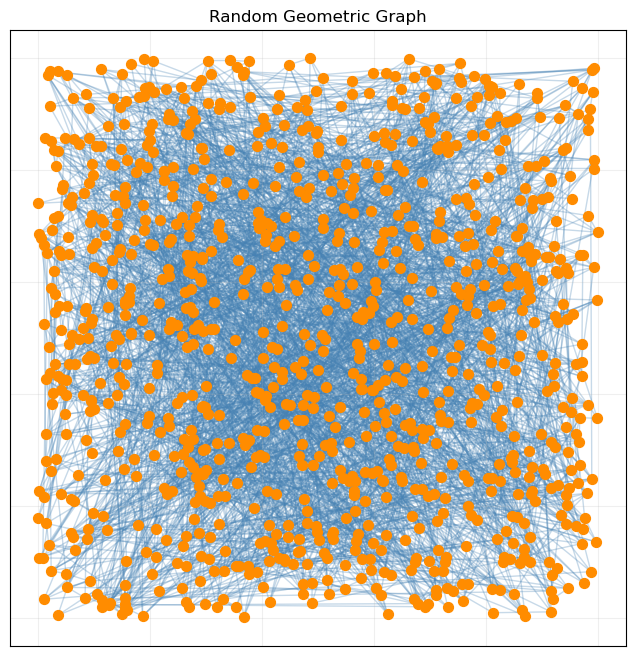

Fichier généré : 1000 nœuds répartis en 100 groupes.


In [149]:
displayGraphPositionNetworkX(G_hybride)
displayGraphPyViz(G_hybride)

## 3 - Graph génération avancée

In [264]:
import graph_tool.all as gt
import numpy as np
import sys
import os
import io
import joblib
import json
from networkx.readwrite import json_graph
from scipy.stats import gaussian_kde
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA


sys.path.append(os.path.abspath("SHAP-like-Graph-Analysis/src"))
import SHAP_like_graph_tool as gp

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [358]:
def get_real_graph_properties_fitness(G_train):
    n_nodes = G_train.number_of_nodes()
    communities = nx.get_node_attributes(G_train, 'sbm_id')
    unique_comms = sorted(list(set(communities.values())))
    mapping = {raw_id: i for i, raw_id in enumerate(unique_comms)}

    embeddings_attr = nx.get_node_attributes(G_train, 'deepwalk')
    sample_emb = next(iter(embeddings_attr.values()))
    emb_dim = len(sample_emb)
    embeddings_matrix = np.zeros((n_nodes, emb_dim))
    for n in range(n_nodes):
        if n in embeddings_attr:
            embeddings_matrix[n] = embeddings_attr[n]
    
    # Extraction des degrés par bloc
    block_fitness = {mapping[c]: [] for c in unique_comms}
    for n, d in G_train.degree():
        block_fitness[mapping[communities[n]]].append(d)
        
    # Modélisation KDE des Fitness par bloc
    block_kdes = {}
    block_means = {}
    for r, fits in block_fitness.items():
        block_means[r] = np.mean(fits)
        if len(fits) > 5 and np.var(fits) > 1e-5:
            block_kdes[r] = gaussian_kde(fits)
        else:
            block_kdes[r] = fits

    # Calcul de la p_matrix (Densité de liens entre blocs)
    sizes = [len(block_fitness[i]) for i in range(len(unique_comms))]
    edge_counts = np.zeros((len(unique_comms), len(unique_comms)))
    for u, v in G_train.edges():
        i, j = mapping[communities[u]], mapping[communities[v]]
        edge_counts[i, j] += 1
        if i != j: edge_counts[j, i] += 1
            
    p_matrix = np.zeros_like(edge_counts)
    for i in range(len(sizes)):
        for j in range(len(sizes)):
            # Nombre max de liens possibles entre bloc i et j
            max_edges = sizes[i] * sizes[j] if i != j else (sizes[i] * (sizes[i]-1)) / 2
            if max_edges > 0:
                p_matrix[i, j] = edge_counts[i, j] / max_edges

    return {
        'block_kdes': block_kdes,
        'block_means': block_means, # Moyenne réelle pour la normalisation
        'p_matrix': p_matrix,
        'sizes': sizes,
        'n_nodes': n_nodes,
        'avg_deg_global': np.mean([d for n, d in G_train.degree()]),
        'embeddings': embeddings_matrix
    }


def generate_hybrid_sbm_fitness(properties, ratio_sbm=1.0, alpha=1.0, show_plots=True):
    sizes = properties['sizes']
    n_nodes = properties['n_nodes']
    embeddings = properties['embeddings']
    b = np.repeat(np.arange(len(sizes)), sizes)
    avg_deg_global = properties['avg_deg_global']
    
    # A. Tirage des Fitness Scores (theta) et calcul des probas de distance (radiation)
    theta = np.zeros(n_nodes)
    for r in range(len(sizes)):
        idx = np.where(b == r)[0]
        kde_or_list = properties['block_kdes'][r]
        
        if hasattr(kde_or_list, 'resample'):
            samples = np.maximum(0.1, kde_or_list.resample(len(idx)).flatten())
        else:
            samples = np.random.choice(kde_or_list, size=len(idx), replace=True).astype(float)
        
        # Normalisation locale : on aligne la moyenne du tirage sur la moyenne réelle du bloc
        m_target = properties['block_means'][r]
        m_current = np.mean(samples)
        theta[idx] = samples * (m_target / m_current) if m_current > 0 else samples

    p_rad_raw = compute_radiation_probs(embeddings, theta, n_components=5, alpha=alpha)
    p_rad_raw = (p_rad_raw + p_rad_raw.T) / 2  # Symétrisation par moyenne (graphe non orienté)
    
    U_sbm = np.zeros((n_nodes, n_nodes))
    U_dist = np.zeros((n_nodes, n_nodes))
    theta_avg_sq = np.mean(theta)**2

    # B. Calcul des probas sbm et dist, puis normalisation pour qu'elles pèsent autant

    for i in range(n_nodes):
        for j in range(i + 1, n_nodes):
            r, s = b[i], b[j]
            # Facteur d'échelle pour compenser le produit des fitness (degrés), basé sur Chung Lu model
            #  P_ij = (theta_i * theta_j / <k>^2) * P_block => Les hubs deviennent très attractifs
            val_sbm = properties['p_matrix'][r, s] * (theta[i] * theta[j]) / (properties['block_means'][r] * properties['block_means'][s])
            U_sbm[i, j] = U_sbm[j, i] = val_sbm
            
            val_dist = p_rad_raw[i, j] * (theta[i] * theta[j]) / theta_avg_sq
            U_dist[i, j] = U_dist[j, i] = val_dist

    # --- C. Normalisation des composantes ---
    for i in range(n_nodes):
        sum_i_sbm = np.sum(U_sbm[i, :])
        sum_i_dist = np.sum(U_dist[i, :])
        if sum_i_dist > 0:
            U_dist[i, :] *= (sum_i_sbm / sum_i_dist)
    
    U_dist = (U_dist + U_dist.T) / 2

    # --- D. Fusion Multiplicative ---
    epsilon = 1e-12
    U_hybrid = np.power(U_sbm + epsilon, ratio_sbm) * np.power(U_dist + epsilon, 1 - ratio_sbm)    

    p_final_matrix = np.zeros((n_nodes, n_nodes))

    for i in range(n_nodes):
        target_degree_i = theta[i]
        row_U = U_hybrid[i, :]
        
        lam_i = 1.0
        for _ in range(5):
            # Formule de type Poisson-Binary : P = 1 - exp(-lambda * U)
            p_row = 1 - np.exp(-lam_i * row_U)
            current_sum = np.sum(p_row)
            if current_sum > 0:
                lam_i *= (target_degree_i / current_sum)
        
        p_final_matrix[i, :] = 1 - np.exp(-lam_i * row_U)

    p_final_matrix = (p_final_matrix + p_final_matrix.T) / 2

    # --- E. Génération des arêtes (Bernoulli) ---
    G_synth = nx.Graph()
    G_synth.add_nodes_from(range(n_nodes))

    # On ne parcourt que le triangle supérieur pour éviter les doublons
    for i in range(n_nodes):
        for j in range(i + 1, n_nodes):
            # p_final est déjà borné dans [0, 1], plus besoin de min(1.0)
            if np.random.random() < p_final_matrix[i, j]:
                G_synth.add_edge(i, j)
    
    nx.set_node_attributes(G_synth, {v: int(b[v]) for v in range(n_nodes)}, 'sbm_id')
    
    if show_plots:
        final_degrees = [d for n, d in G_synth.degree()]
        # On passe target_links calculé sur theta pour comparaison
        _plot_generation_diagnostics(sizes, theta, final_degrees, G_synth.number_of_edges())
        
    print(f"Graphe SBM Fitness généré : {G_synth.number_of_edges()} liens (Cible : {int(np.sum(theta)/2)})")
    return G_synth

def compute_radiation_probs(embeddings, theta, n_components=5, alpha=1.0):
    n = len(theta)
    pca = PCA(n_components=n_components)
    latent_pos_reduced = pca.fit_transform(embeddings)
    
    shuffled_idx = np.random.permutation(n)
    pos = latent_pos_reduced[shuffled_idx]
    shuffled_theta = theta[shuffled_idx] # Aligner theta sur les nouvelles positions
    
    dist_matrix = cdist(pos, pos, metric='euclidean')
    p_rad = np.zeros((n, n))
    
    for i in range(n):
        dists = dist_matrix[i]
        sorted_idx = np.argsort(dists)
        cum_theta = np.cumsum(shuffled_theta[sorted_idx]) ### taille N
        
        total_in_circle = np.zeros(n)
        total_in_circle[sorted_idx] = cum_theta
        
        # s_ij est la somme des fitness strictement entre i et j
        # total_in_circle - theta[i] - theta[j]
        s_ij = np.maximum(0.1, total_in_circle - shuffled_theta[i] - shuffled_theta)
        
        # Formule originale : Pij = (mi * mj) / ((mi + sij) * (mi + mj + sij))
        # Adpatée ici en 1/(1 + sij) car le poids des noeuds sera pris en compte dans la méthode de construction, de la même manière
        # que pour les probas issues de sbm. Moins de biais (dans l'idée)
        m_i = theta[i]
        m_j = theta
        #denom = (m_i + s_ij) * (m_i + m_j + s_ij)
        denom = (1 + s_ij**alpha)
        
        p_rad_shuffled_row = np.divide(1, denom, where=denom!=0)
        
        # On remetla ligne dans l'ordre original pour la fusion finale avec le SBM
        reverse_idx = np.argsort(shuffled_idx)
        p_rad[shuffled_idx[i]] = p_rad_shuffled_row[reverse_idx]
    
    np.fill_diagonal(p_rad, 0)
    return p_rad


def _plot_generation_diagnostics(sizes, target_fitness, final_degrees, num_edges):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.bar(range(len(sizes)), sizes, color='skyblue', edgecolor='black', alpha=0.7)
    ax1.set_title("Tailles des Blocs (SBM)")
    
    # Distribution des degrés (Log-Log)
    k_target, c_target = np.unique(np.round(target_fitness), return_counts=True)
    ax2.loglog(k_target, c_target, 'go', alpha=0.4, label='Fitness (Cible)')
    
    k_final, c_final = np.unique(final_degrees, return_counts=True)
    ax2.loglog(k_final, c_final, 'rx', alpha=0.8, label='Final (Généré)')
    
    ax2.set_title(f"Distribution des Degrés ({num_edges} edges)")
    ax2.set_xlabel("Degré k")
    ax2.set_ylabel("N(k)")
    ax2.legend()
    plt.show()

def save_synthetic_graph(G, filename):
    base_dir = "SHAP-like-Graph-Analysis/graph_library"
    full_path = os.path.join(base_dir, filename)
    
    data = json_graph.node_link_data(G)
    with open(full_path, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=4)
    
    print(f" Graphe sauvegardé avec succès : {full_path}")
    print(f" Statistiques : {G.number_of_nodes()} nœuds, {G.number_of_edges()} liens.")

1988
362
reel_facebook_friends_w_attributes


/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var


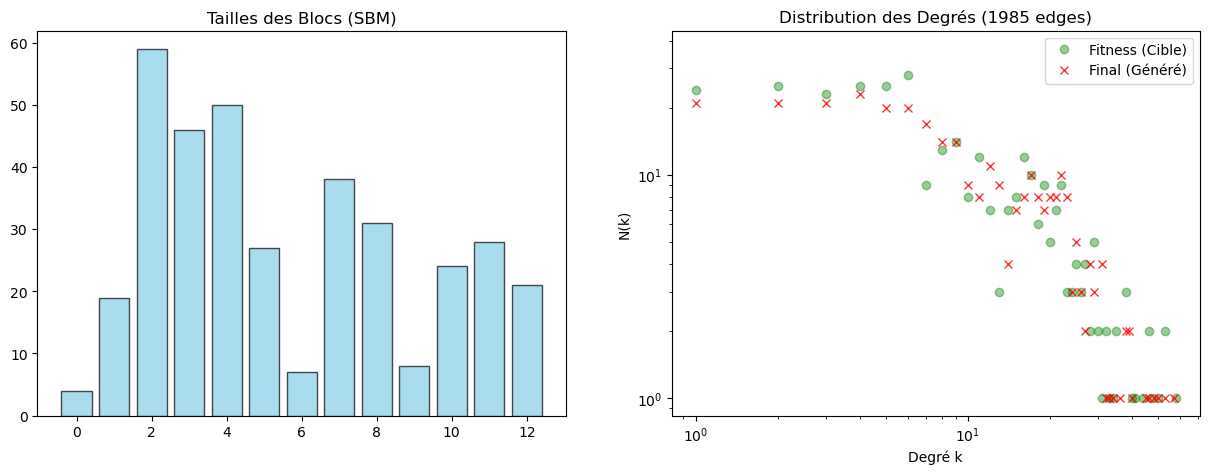

Graphe SBM Fitness généré : 1985 liens (Cible : 1988)
1985
362
 Graphe sauvegardé avec succès : SHAP-like-Graph-Analysis/graph_library/artificial_graph_sbmv2_1_00_pos_0_00.json
 Statistiques : 362 nœuds, 1985 liens.


/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:142: FutureWarning: 
The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.
  warnings.warn(


In [371]:
G_name = "reel_facebook_friends_w_attributes"
path = f"SHAP-like-Graph-Analysis/graph_library/{G_name}"
G = joblib.load(path)
print(G.number_of_edges())
print(G.number_of_nodes())

properties = get_real_graph_properties_fitness(G)
ratio_sbm = 1.00
G_name_bis = f"artificial_graph_sbmv2_{ratio_sbm:.2f}_pos_{1 - ratio_sbm:.2f}".replace('.', '_') + ".json"
print(G_name)

test = generate_hybrid_sbm_fitness(properties,ratio_sbm=ratio_sbm, show_plots=True, alpha = 0.7)
print(test.number_of_edges())
print(test.number_of_nodes())

save_synthetic_graph(test, G_name_bis)

## 4 - Generation papier - friendly (tentative)

In [62]:
import graph_tool.all as gt
import graph_tool.clustering as gt_clust
from graph_tool.spectral import adjacency
import numpy as np
import pandas as pd
import networkx as nx
import sys
import os
import joblib
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

sys.path.append(os.path.abspath("src"))
import SHAP_like_graph_tool as gp

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### FCTS génération graphe - V1

In [75]:
def get_real_graph_properties_sbm(G_train):
    nodes = list(G_train.nodes())
    communities = nx.get_node_attributes(G_train, 'sbm_id')
    unique_comms = sorted(list(set(communities.values())))
    mapping = {raw_id: i for i, raw_id in enumerate(unique_comms)}
    n_comms = len(unique_comms)
    
    probs = np.zeros((n_comms, n_comms))
    b = []        # Vecteur d'appartenance aux blocs (ex: [0, 0, 1, 0, 2...])
    degrees = []  # Vecteur des degrés observés (ex: [12, 5, 22, ...])
    
    for node in nodes:
        b.append(mapping[communities[node]])
        degrees.append(G_train.degree(node))
    
    for u, v in G_train.edges():
        comm_u = mapping[communities[u]]
        comm_v = mapping[communities[v]]
        if comm_u == comm_v:
            probs[comm_u, comm_u] += 2
        else:
            probs[comm_u, comm_v] += 1
            probs[comm_v, comm_u] += 1

    b = np.array(b, dtype=np.int32)
    degrees = np.array(degrees, dtype=np.int32)
            
    return b, probs, degrees

def get_real_graph_properties_pos(G_train, n_components=2, shuffle=True):
    nodes = list(G_train.nodes())
    embeddings_attr = nx.get_node_attributes(G_train, 'deepwalk')
    raw_embeddings = np.array([embeddings_attr[node] for node in nodes])
    
    # On réduit les dimensions des embeddings pour éviter des distances trop grandes. Utile ?
    pca = PCA(n_components=n_components, random_state=42)
    pos_reduced = pca.fit_transform(raw_embeddings)
    
    # Normalisation dans [0;1], standard pour modèles spatiaux askip
    pos_min = pos_reduced.min(axis=0)
    pos_max = pos_reduced.max(axis=0)
    pos_normalized = (pos_reduced - pos_min) / (pos_max - pos_min)
    
    if shuffle:
        rng = np.random.default_rng(seed=42)
        shuffled_indices = rng.permutation(len(pos_normalized))
        pos_final = pos_normalized[shuffled_indices]
    else:
        pos_final = pos_normalized
        
    return pos_final

def generate_sbm_graph(b, target_probs, degrees):
    n_nodes = len(b)
    n_blocks = target_probs.shape[0]
    
    g_final = gt.Graph(directed=False)
    g_final.add_vertex(n_nodes)
    
    remaining_probs = target_probs.copy()
    prev_edges = 0
    iteration = 0
    
    while np.sum(remaining_probs) > 1 and iteration < 15:
        g_temp = gt.generate_sbm(b, remaining_probs, degrees, degrees, directed=False, micro_ers=False, micro_degs=False)
        
        g_final.add_edge_list(g_temp.get_edges())
        gt.remove_self_loops(g_final)
        gt.remove_parallel_edges(g_final)
        
        current_edges = g_final.num_edges()
        if current_edges <= prev_edges: break
        prev_edges = current_edges
        
        current_counts = np.zeros((n_blocks, n_blocks))
        edges = g_final.get_edges()
        for u, v in edges[:,:2]:
            r, s = b[u], b[v]
            if r == s:
                current_counts[r, r] += 2 #
            else:
                current_counts[r, s] += 1
                current_counts[s, r] += 1 
        
        remaining_probs = np.maximum(0, target_probs - current_counts)
        iteration += 1

        if iteration%5 ==0 : 
            print(f"Iter {iteration}: Reste {np.sum(remaining_probs):.1f} liens à placer")
        
    return g_final

def generate_DC_spatial_graph(degrees, positions, sigma=0.1):
    n_nodes = len(degrees)
    sum_k = np.sum(degrees)
    theta = np.array(degrees) / np.sqrt(sum_k) 
    
    dist_matrix = squareform(pdist(positions, 'euclidean'))
    kernel = np.exp(-(dist_matrix**2) / (2 * sigma**2))
    
    P = np.outer(theta, theta) * kernel # P_ij = theta_i * theta_j * kernel_ij 
    # => NOTE INTUITIVE : la somme des theta_i * theta_j = NB de lien souhaité. C'est donc normal qu'on "manque" de liens en ajoutant la dist.
    # La normalisation dans ce cas ne me semble pas être du bricolage.
    np.fill_diagonal(P, 0)
    
    # Normalisation
    target_L = sum_k / 2
    current_L = np.sum(P) / 2 
    adjustment_factor = target_L / current_L
    P *= adjustment_factor
    print(f"Probabilité normalisées, par un facteur {adjustment_factor}")
        
    n_clipped = (P > 1).sum()
    if n_clipped > 0:
        print(f"Warning: {n_clipped} probabilités plafonnées à 1.0 (Sigma trop petit ?)")
    P = np.clip(P, 0, 1)
    
    # Génération du graphe
    g = gt.Graph(directed=False)
    g.add_vertex(n_nodes)
    
    # Utilisation de la méthode efficace pour ajouter les arêtes
    upper_idx = np.triu_indices(n_nodes, k=1)
    mask = np.random.random(len(upper_idx[0])) < P[upper_idx]
    
    edges = np.column_stack((upper_idx[0][mask], upper_idx[1][mask]))
    g.add_edge_list(edges)
    
    return g,P

### FCTS Plots, Entropy, Variance vérif, V1

In [10]:
def plot_degree_correlation(degrees_orig, g_sbm, g_spatial):
    """
    Compare les degrés du graphe original avec les versions SBM et Spatial.
    """
    degs_sbm = [v.out_degree() for v in g_sbm.vertices()]
    degs_spatial = [v.out_degree() for v in g_spatial.vertices()]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    
    # --- Sous-graphe 1 : SBM ---
    ax1.scatter(degrees_orig, degs_sbm, alpha=0.5, color='royalblue', label='Noeuds')
    ax1.plot([0, max(degrees_orig)], [0, max(degrees_orig)], 'r--', label='Identité (Parfait)')
    ax1.set_title("Fidélité des degrés : SBM Pure")
    ax1.set_xlabel("Degré Original (G_train)")
    ax1.set_ylabel("Degré Généré")
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()
    
    # --- Sous-graphe 2 : Spatial ---
    ax2.scatter(degrees_orig, degs_spatial, alpha=0.5, color='forestgreen', label='Noeuds')
    ax2.plot([0, max(degrees_orig)], [0, max(degrees_orig)], 'r--', label='Identité (Parfait)')
    ax2.set_title(f"Fidélité des degrés : Spatial Pure")
    ax2.set_xlabel("Degré Original (G_train)")
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # 3. Métrique d'erreur (MAE)
    mae_sbm = np.mean(np.abs(np.array(degrees_orig) - np.array(degs_sbm)))
    mae_spatial = np.mean(np.abs(np.array(degrees_orig) - np.array(degs_spatial)))
    
    print(f"Erreur Moyenne Absolue (MAE) SBM     : {mae_sbm:.2f}")
    print(f"Erreur Moyenne Absolue (MAE) Spatial : {mae_spatial:.2f}")

def check_spatial_dominance(g, positions):
    dists = []
    for e in g.edges():
        p1 = positions[int(e.source())]
        p2 = positions[int(e.target())]
        dists.append(np.linalg.norm(p1 - p2))
    
    avg_dist = np.mean(dists)
    
    # 2. Coefficient de clustering
    cc = gt_clust.global_clustering(g)[0]
    
    print(f"Distance moyenne des liens : {avg_dist:.3f} (Espace théorique : 0.521)")
    print(f"Coefficient de Clustering  : {cc:.3f}")


def calculate_graph_entropy_dist(P):
    upper_idx = np.triu_indices_from(P, k=1)
    p_vector = P[upper_idx]
    
    epsilon = 1e-12
    p_vector = np.clip(p_vector, epsilon, 1 - epsilon)
    
    # Formule de l'entropie binaire : H = - [p*log2(p) + (1-p)*log2(1-p)]
    h_binaire = -(p_vector * np.log2(p_vector) + (1 - p_vector) * np.log2(1 - p_vector))
    total_entropy = np.sum(h_binaire)
    
    return total_entropy

def calculate_sbm_theoretical_entropy(b, block_probs, degrees):
    n = len(degrees)
    P = np.zeros((n, n))
    unique_blocks = np.unique(b)
    
    # Pré-calcul des sommes de degrés par bloc
    sum_k_blocks = {r: np.sum(degrees[b == r]) for r in unique_blocks}

    for r in unique_blocks:
        for s in unique_blocks:
            if r > s: continue
            
            idx_r = np.where(b == r)[0]
            idx_s = np.where(b == s)[0]
            p_rs = block_probs[r, s]
            
            if sum_k_blocks[r] == 0 or sum_k_blocks[s] == 0: continue

            # Probabilité de base du Sampler
            # On multiplie les probabilités relatives des degrés
            # k_i/sum_k_r * k_j/sum_k_s
            norm_factor = sum_k_blocks[r] * sum_k_blocks[s]
            block_P = np.outer(degrees[idx_r], degrees[idx_s]) * (p_rs / norm_factor)
            
            if r == s:
                # IMPORTANT : Pour r == s, le code C++ tire mrs fois, 
                # mais pour un graphe non-orienté, p_rs est divisé par 2 au début, 
                # puis ers est mrs * 2. 
                # Au final, la probabilité ij est (P_i * P_j + P_j * P_i) * p_rs_initial / 2
                # Ce qui revient simplement à block_P tel quel, mais il faut 
                # s'assurer de ne pas compter la diagonale.
                P[np.ix_(idx_r, idx_s)] = block_P
            else:
                P[np.ix_(idx_r, idx_s)] = block_P
                P[np.ix_(idx_s, idx_r)] = block_P.T

    # On retire les auto-boucles (le Sampler C++ peut en générer mais elles sont souvent retirées)
    np.fill_diagonal(P, 0)
    
    # Clip pour éviter les log(0)
    P = np.clip(P, 1e-15, 1 - 1e-15)
    
    upper_idx = np.triu_indices(n, k=1)
    p_vector = P[upper_idx]
    
    # Entropie de Bernoulli (base 2 pour les bits)
    h_binaire = -(p_vector * np.log2(p_vector) + (1 - p_vector) * np.log2(1 - p_vector))
    
    return np.sum(h_binaire), P

def calculate_log_likelihood(G, P):
    if isinstance(G, nx.Graph):
        adj = nx.to_numpy_array(G, nodelist=range(len(P)))
    else:
        adj = adjacency(G).toarray()

    upper_idx = np.triu_indices_from(P, k=1)
    p_vector = np.clip(P[upper_idx], 1e-12, 1 - 1e-12)
    adj_vector = adj[upper_idx]

    log_likelihood = np.sum(adj_vector * np.log2(p_vector) + (1 - adj_vector) * np.log2(1 - p_vector))
    
    return log_likelihood

### FCTS génération graphe - V2

In [59]:
def get_real_graph_properties_sbm_V2(G_train):
    nodes_map = {node: i for i, node in enumerate(G_train.nodes())}
    edges = [(nodes_map[u], nodes_map[v]) for u, v in G_train.edges()]    
    communities = nx.get_node_attributes(G_train, 'sbm_id')
    unique_comms = sorted(list(set(communities.values())))
    mapping = {raw_id: i for i, raw_id in enumerate(unique_comms)}
    
    g = gt.Graph(directed=False)
    g.add_vertex(len(G_train.nodes()))
    g.add_edge_list(edges)
    
    b_array = np.array([mapping[communities[node]] for node in G_train.nodes()])
    b_prop = g.new_vertex_property("int", b_array)

    state = gt.BlockState(g, b=b_prop, deg_corr=True)

    # La matrice de liens entre blocs (e_rs)
    e_rs = state.get_matrix().toarray()
    
    # Les degrés de chaque nœud (k_i)
    k = g.get_out_degrees(g.get_vertices())
    
    return e_rs, k, b_array

def get_real_graph_properties_pos_V2(G_train, n_components=4, shuffle=True):
    nodes = list(G_train.nodes())
    embeddings_attr = nx.get_node_attributes(G_train, 'deepwalk')
    raw_embeddings = np.array([embeddings_attr[node] for node in nodes])
    degrees = []
    
    for node in nodes:
        degrees.append(G_train.degree(node))
    
    # On réduit les dimensions des embeddings pour éviter des distances trop grandes. Utile ?
    pca = PCA(n_components=n_components, random_state=42)
    pos_reduced = pca.fit_transform(raw_embeddings)
    
    # Normalisation dans [0;1], standard pour modèles spatiaux askip
    pos_min = pos_reduced.min(axis=0)
    pos_max = pos_reduced.max(axis=0)
    pos_normalized = (pos_reduced - pos_min) / (pos_max - pos_min)
        
    if shuffle:
        rng_pos = np.random.default_rng(seed=42)
        idx_pos = rng_pos.permutation(len(pos_normalized))
        pos_final = pos_normalized[idx_pos]
        
        rng_deg = np.random.default_rng(seed=99) 
        idx_deg = rng_deg.permutation(len(degrees))
        degrees_final = np.array(degrees)[idx_deg]
    else:
        degrees_final = pos_normalized
        
    return degrees_final, pos_final

def get_probs_sbm(e_rs, k, b):
    e_r = e_rs.sum(axis=1)
    n = len(k)
    n_blocks = e_rs.shape[0]
    P = np.zeros((n, n))
    
    for r in range(n_blocks):
        for s in range(r, n_blocks):
            idx_r = np.where(b == r)[0]
            idx_s = np.where(b == s)[0]
            if e_r[r] == 0 or e_r[s] == 0: continue
            
            # Formule de Karrer & Newman
            block_p = np.outer(k[idx_r], k[idx_s]) * (e_rs[r, s] / (e_r[r] * e_r[s]))
            
            P[np.ix_(idx_r, idx_s)] = block_p
            if r != s:
                P[np.ix_(idx_s, idx_r)] = block_p.T

    np.fill_diagonal(P, 0)

    n_clipped = np.sum(P[np.triu_indices(n, k=1)] > 1.0)
    if n_clipped > 0:
        print(f"Warning: {int(n_clipped)} probabilités SBM plafonnées à 1.0 (Hubs importants)")
    P = np.clip(P, 0, 1)
    
    return P

def get_probs_spatial(degrees, positions, sigma=1.0, iterations=4000, lr=0.2):
    n = len(degrees)
    k = np.array(degrees, dtype=float)
    dist_matrix = squareform(pdist(positions, 'euclidean'))
    
    alpha = np.log(k + 1e-5)
    
    for _ in range(iterations):
        # Logit = alpha_i + alpha_j - sigma * dist_ij
        logit = alpha[:, np.newaxis] + alpha[np.newaxis, :] - sigma * dist_matrix
        P = 1.0 / (1.0 + np.exp(-logit))
        np.fill_diagonal(P, 0)
        
        # 2. Erreur sur les degrés
        current_degs = P.sum(axis=1)
        diff = k - current_degs
        
        # 3. Mise à jour des potentiels (Descente de gradient)
        alpha += lr * diff / n 

    n_sattures = (P > 0.99).sum()
    print(f"Warning: {n_sattures} probabilités saturées à +0.99")
    mae_deg = np.mean(np.abs(P.sum(axis=1) - degrees))
    print(f"Erreur moyenne sur les degrés (MAE) : {mae_deg:.6f}")
        
    return P

def get_probs_spatial_mid(degrees, positions, sigma=0.1, iterations=30):
    n = len(degrees)
    k = np.array(degrees, dtype=float)
    
    dist_matrix = squareform(pdist(positions, 'euclidean'))
    #kernel = 1.0 / (1.0 + (dist_matrix / sigma)**2)
    kernel = np.exp(-(dist_matrix**2) / (2 * sigma**2))
    np.fill_diagonal(kernel, 0)

    A = np.sqrt(k / np.mean(k)) 

    for _ in range(iterations):
        P_temp = np.outer(A, A) * kernel
        
        # ICI : On calcule le résidu de degré
        # On utilise une version "tronquée" pour que A sache qu'il est au max
        current_degs = np.minimum(P_temp, 1.0).sum(axis=1)
        current_degs = np.maximum(current_degs, 1e-9)
        
        # Mise à jour Newton-Raphson (plus rapide pour les hubs)
        # Au lieu de sqrt(k/curr), on utilise un ratio direct pondéré
        A *= (k / current_degs) ** 0.8 # Puissance 0.8 = compromis stabilité/vitesse
        
        A = np.clip(A, 1e-10, 1e150)

    P = np.outer(A, A) * kernel
    
    n_clipped = (P > 1.0).sum() / 2
    P = np.clip(P, 0, 1)
    print(f"Warning: {n_clipped} probabilités plafonnées à 1.0 (Sigma trop petit ?)")
    
    mae_degs = np.mean(np.abs(P.sum(axis=1) - k))
    print(f"Modèle Gravitaire (Idé et al.) stabilisé. MAE degrés: {mae_degs:.4f}")
    
    return P

def get_probs_spatial_sinkhorn(degrees, positions, sigma=0.1, iterations=10):
    n = len(degrees)
    sum_k = np.sum(degrees)
    theta = np.array(degrees) / np.sqrt(sum_k) 
    
    dist_matrix = squareform(pdist(positions, 'euclidean'))
    kernel = np.exp(-(dist_matrix**2) / (2 * sigma**2))
    
    P = np.outer(theta, theta) * kernel # P_ij = theta_i * theta_j * kernel_ij 
    # => NOTE INTUITIVE : la somme des theta_i * theta_j = NB de lien souhaité. C'est donc normal qu'on "manque" de liens en ajoutant la dist.
    # La normalisation dans ce cas ne me semble pas être du bricolage.
    np.fill_diagonal(P, 0)

    # Équilibrage itératif (Type Sinkhorn simplifié)
    # On ajuste pour que la somme des lignes de P soit égale aux degrés k
    for _ in range(iterations):
        # Ajustement des lignes
        row_sums = P.sum(axis=1)
        row_sums[row_sums == 0] = 1
        P *= (degrees / row_sums)[:, np.newaxis]
        
        # On clip doucement à chaque étape pour éviter l'explosion
        P = np.clip(P, 0, 1)
        
        # Ajustement des colonnes (symétrie)
        col_sums = P.sum(axis=0)
        col_sums[col_sums == 0] = 1
        P *= (degrees / col_sums)[np.newaxis, :]
        P = np.clip(P, 0, 1)

    n_clipped = (P > 0.99).sum()
    print(f"Warning: {n_clipped} probabilités saturées à +0.99 (Sigma trop petit ?)")
    mae_deg = np.mean(np.abs(P.sum(axis=1) - degrees))
    print(f"Erreur moyenne sur les degrés (MAE) : {mae_deg:.6f}")

    return P
    
def generate_graph_from_probs(P):
    n = P.shape[0]
    g = gt.Graph(directed=False)
    g.add_vertex(n)
    
    upper_idx = np.triu_indices(n, k=1)
    probs_vector = P[upper_idx]
    
    mask = np.random.random(len(probs_vector)) < probs_vector
    edges = np.column_stack((upper_idx[0][mask], upper_idx[1][mask]))
   
    g.add_edge_list(edges)
    
    return g

### FCTS Plots, Entropy, Variance vérif, V2

In [73]:
def get_variance_from_P(P):
    n = P.shape[0]
    upper_idx = np.triu_indices(n, k=1)
    
    p_vector = P[upper_idx].copy()
    variance = np.var(p_vector)
    
    return variance

def plot_degree_correlation(degrees_orig, g_sbm, g_spatial):
    degs_sbm = [v.out_degree() for v in g_sbm.vertices()]
    degs_spatial = [v.out_degree() for v in g_spatial.vertices()]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    
    # --- Sous-graphe 1 : SBM ---
    ax1.scatter(degrees_orig, degs_sbm, alpha=0.5, color='royalblue', label='Noeuds')
    ax1.plot([0, max(degrees_orig)], [0, max(degrees_orig)], 'r--', label='Identité (Parfait)')
    ax1.set_title("Fidélité des degrés : SBM Pure")
    ax1.set_xlabel("Degré Original (G_train)")
    ax1.set_ylabel("Degré Généré")
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()
    
    # --- Sous-graphe 2 : Spatial ---
    ax2.scatter(degrees_orig, degs_spatial, alpha=0.5, color='forestgreen', label='Noeuds')
    ax2.plot([0, max(degrees_orig)], [0, max(degrees_orig)], 'r--', label='Identité (Parfait)')
    ax2.set_title(f"Fidélité des degrés : Spatial Pure")
    ax2.set_xlabel("Degré Original (G_train)")
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # 3. Métrique d'erreur (MAE)
    mae_sbm = np.mean(np.abs(np.array(degrees_orig) - np.array(degs_sbm)))
    mae_spatial = np.mean(np.abs(np.array(degrees_orig) - np.array(degs_spatial)))
    
    print(f"Erreur Moyenne Absolue (MAE) SBM     : {mae_sbm:.2f}")
    print(f"Erreur Moyenne Absolue (MAE) Spatial : {mae_spatial:.2f}")

def plot_degree_distribution(degrees_orig, g_sbm, g_spatial, g_test, label_test="Hybride"):
    d_sbm, d_spat, d_test = [[v.out_degree() for v in g.vertices()] for g in [g_sbm, g_spatial, g_test]]
    fig, ax = plt.subplots(figsize=(10, 6))
    params = {'bw_adjust': 0.2, 'cut': 0, 'gridsize': 200}
    
    # Courbes de densité
    sns.kdeplot(degrees_orig, ax=ax, color='#7f8c8d', label='Original', fill=True, alpha=0.1, linewidth=1, linestyle='--', **params)
    sns.kdeplot(d_sbm, ax=ax, color='#5d6d7e', label='SBM Pur', linewidth=1.5, alpha=0.8, **params)
    sns.kdeplot(d_spat, ax=ax, color='#a93226', label='Spatial Pur', linewidth=1.5, alpha=0.5, linestyle=':', **params)
    sns.kdeplot(d_test, ax=ax, color='#d35400', label=label_test, linewidth=3, alpha=1.0, **params)

    # Cosmétique
    ax.set_title("Densités de Degrés : Impact de l'hybridation décorrélée", fontsize=12, pad=15)
    ax.set_xlabel("Degré (k)"); ax.set_ylabel("Densité"); ax.grid(True, linestyle=':', alpha=0.5)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False); ax.legend(frameon=False)
    plt.tight_layout(); plt.show()

    # Stats KS
    print(f"KS Distances -> SBM: {ks_2samp(degrees_orig, d_sbm).statistic:.4f} | Spatial: {ks_2samp(degrees_orig, d_spat).statistic:.4f} | {label_test}: {ks_2samp(degrees_orig, d_test).statistic:.4f}")
    print(f"Moyennes -> Orig: {np.mean(degrees_orig):.2f} | {label_test}: {np.mean(d_test):.2f}")
    print(f"Std -> Orig: {np.std(degrees_orig):.2f} | {label_test}: {np.std(d_test):.2f}")

def get_entropy_from_p(P):
    upper_idx = np.triu_indices_from(P, k=1)
    p_vector = P[upper_idx]
    
    epsilon = 1e-12
    p_vector = np.clip(p_vector, epsilon, 1 - epsilon)
    
    # Formule de l'entropie binaire : H = - [p*log2(p) + (1-p)*log2(1-p)]
    h_binaire = -(p_vector * np.log2(p_vector) + (1 - p_vector) * np.log2(1 - p_vector))
    total_entropy = np.sum(h_binaire)
    
    return total_entropy

def get_log_likelihood(G, P):
    if isinstance(G, nx.Graph):
        adj = nx.to_numpy_array(G, nodelist=range(len(P)))
    else:
        adj = adjacency(G).toarray()

    upper_idx = np.triu_indices_from(P, k=1)
    p_vector = np.clip(P[upper_idx], 1e-12, 1 - 1e-12)
    adj_vector = adj[upper_idx]

    log_likelihood = np.sum(adj_vector * np.log2(p_vector) + (1 - adj_vector) * np.log2(1 - p_vector))
    
    return log_likelihood

def analyze_errors(G, P):
    adj = adjacency(G).toarray()
    upper = np.triu_indices_from(P, k=1)
    p_vec = P[upper]
    a_vec = adj[upper]
    
    surprises = p_vec[a_vec == 1]
    print(f"Proba moyenne pour les arêtes réelles : {np.mean(surprises):.6f}")
    print(f"Proba min pour une arête réelle : {np.min(surprises):.12f}")
    
    critiques = np.sum(surprises < 1e-4)
    print(f"Nombre d'arêtes 'impossibles' selon le modèle : {critiques}")

import networkx as nx

def convert_to_nx_with_metadata(gt_graph, positions, sbm_labels):
    edges = gt_graph.get_edges()
    n_nodes = len(sbm_labels)
    G_nx = nx.Graph()
    G_nx.add_nodes_from(range(n_nodes))
    G_nx.add_edges_from(edges)
    
    n_dim = positions.shape[1] # Nombre de dimensions PCA
    
    for i in range(n_nodes):
        G_nx.nodes[i]['sbm_id'] = int(sbm_labels[i])
        
        for d in range(n_dim):
            G_nx.nodes[i][f'pca_{d}'] = float(positions[i, d])
            
    return G_nx

def save_as_graphml(G_nx, filename="mon_graphe.graphml", folder="graph_library"):
    path = os.path.join(folder, filename)
    nx.write_graphml(G_nx, path)
    print(f"Graphe exporté avec succès dans : {path}")

### Utilisation

1988
362
Erreur moyenne sur les degrés (MAE) : 0.061015
SBM VS spatial = 1895 VS 2045
 Entropy VS Log_likelyhood SBM : 4769.025989100336 / -4853.510209727295
 Entropy VS Log_likelyhood Spatial : 5365.24464903211 / -5382.400467406911
 Variance SBM VS Spatial : 0.013423143443452863 / 0.013423150760514514


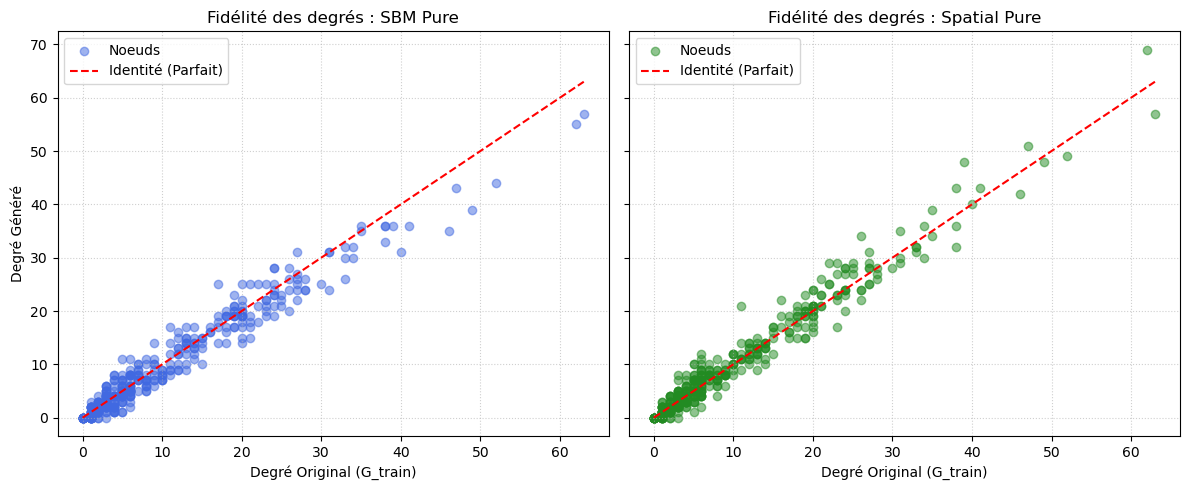

Erreur Moyenne Absolue (MAE) SBM     : 1.74
Erreur Moyenne Absolue (MAE) Spatial : 1.55
Proba moyenne pour les arêtes réelles : 0.469804
Proba min pour une arête réelle : 0.000155471801
Nombre d'arêtes 'impossibles' selon le modèle : 0
Proba moyenne pour les arêtes réelles : 0.492655
Proba min pour une arête réelle : 0.000249750250
Nombre d'arêtes 'impossibles' selon le modèle : 0


In [47]:
G_name = "reel_facebook_friends_w_attributes"
path = f"graph_library/{G_name}"
G = joblib.load(path)
print(G.number_of_edges())
print(G.number_of_nodes())

e_rs, k, b = get_real_graph_properties_sbm_V2(G)
P_sbm = get_probs_sbm(e_rs, k, b)

degrees, position = get_real_graph_properties_pos_V2(G)
P_spatial = get_probs_spatial(degrees, position, sigma= 12.6738)
#P_spatial = get_probs_spatial_sinkhorn(degrees, position, sigma=0.282)

g_sbm = generate_graph_from_probs(P_sbm)
g_spatial = generate_graph_from_probs(P_spatial)
print(f"SBM VS spatial = {g_sbm.num_edges()} VS {g_spatial.num_edges()}")

entropy_sbm = get_entropy_from_p(P_sbm)
log_likelyhood_sbm = get_log_likelihood(g_sbm, P_sbm)
entropy_spatial = get_entropy_from_p(P_spatial)
log_likelyhood_spatial = get_log_likelihood(g_spatial, P_spatial)
var_sbm = get_variance_from_P(P_sbm)
var_spatial = get_variance_from_P(P_spatial)

print(f" Entropy VS Log_likelyhood SBM : {entropy_sbm} / {log_likelyhood_sbm}")
print(f" Entropy VS Log_likelyhood Spatial : {entropy_spatial} / {log_likelyhood_spatial}")
print(f" Variance SBM VS Spatial : {var_sbm} / {var_spatial}")


plot_degree_correlation(k, g_sbm, g_spatial)


analyze_errors(g_spatial, P_spatial)
analyze_errors(g_sbm, P_sbm)

### Equilibrage de la variance entre les 2 modèles (SBM VS spatial)

In [20]:
from scipy.optimize import minimize_scalar

def match_spatial_to_sbm_variance(P_sbm, degrees, positions):
    target_variance = get_variance_from_P(P_sbm)
    print(f"Variance cible (SBM) : {target_variance:.8f}")
    print("-" * 30)

    history = {'step': 0}

    def objective(sigma_test):
        history['step'] += 1
        
        P_test = get_probs_spatial(degrees, positions, sigma=sigma_test)
        current_var = get_variance_from_P(P_test)
        diff = abs(current_var - target_variance)
        
        print(f"Step {history['step']:02d} | Sigma testé: {sigma_test:.4f} | Var: {current_var:.8f} | Δ: {diff:.2e}")
        
        return (current_var - target_variance)**2

    res = minimize_scalar(objective, bounds=(0.005, 50), method='bounded')
    
    print("-" * 30)
    opt_sigma = res.x
    
    final_P_spatial = get_probs_spatial(degrees, positions, sigma=opt_sigma)
    final_var = get_variance_from_P(final_P_spatial)
    
    print(f"✨ Sigma optimal trouvé : {opt_sigma:.4f}")
    print(f"📊 Variance finale Spatial : {final_var:.8f} (Écart: {abs(final_var-target_variance):.2e})")
    
    return opt_sigma, final_P_spatial

for i in range(4,5):
    print("==================================")
    print(f"============ i = {i} =============")
    print("==================================")
    
    e_rs, k, b = get_real_graph_properties_sbm_V2(G)
    P_sbm = get_probs_sbm(e_rs, k, b)
    
    degrees_spatial, pos_spatial = get_real_graph_properties_pos_V2(G, i)
    
    sigma_opt, P_spatial_calibrated = match_spatial_to_sbm_variance(P_sbm, degrees_spatial, pos_spatial)

============ i = 4 =============
Variance cible (SBM) : 0.01342314
------------------------------
Erreur moyenne sur les degrés (MAE) : 0.134955
Step 01 | Sigma testé: 19.1014 | Var: 0.01613247 | Δ: 2.71e-03
Erreur moyenne sur les degrés (MAE) : 0.262974
Step 02 | Sigma testé: 30.9036 | Var: 0.01894879 | Δ: 5.53e-03
Erreur moyenne sur les degrés (MAE) : 0.052821
Step 03 | Sigma testé: 11.8072 | Var: 0.01293267 | Δ: 4.90e-04
Erreur moyenne sur les degrés (MAE) : 0.016815
Step 04 | Sigma testé: 6.0829 | Var: 0.00819583 | Δ: 5.23e-03
Erreur moyenne sur les degrés (MAE) : 0.078458
Step 05 | Sigma testé: 14.3437 | Var: 0.01426542 | Δ: 8.42e-04
Erreur moyenne sur les degrés (MAE) : 0.059495
Step 06 | Sigma testé: 12.5178 | Var: 0.01333780 | Δ: 8.53e-05
Erreur moyenne sur les degrés (MAE) : 0.061730
Step 07 | Sigma testé: 12.7466 | Var: 0.01346254 | Δ: 3.94e-05
Erreur moyenne sur les degrés (MAE) : 0.060987
Step 08 | Sigma testé: 12.6710 | Var: 0.01342161 | Δ: 1.53e-06
Erreur moyenne sur les 

### Génération des hybrides : 

Erreur moyenne sur les degrés (MAE) : 0.082767

Pour ratio_sbm = 0.1



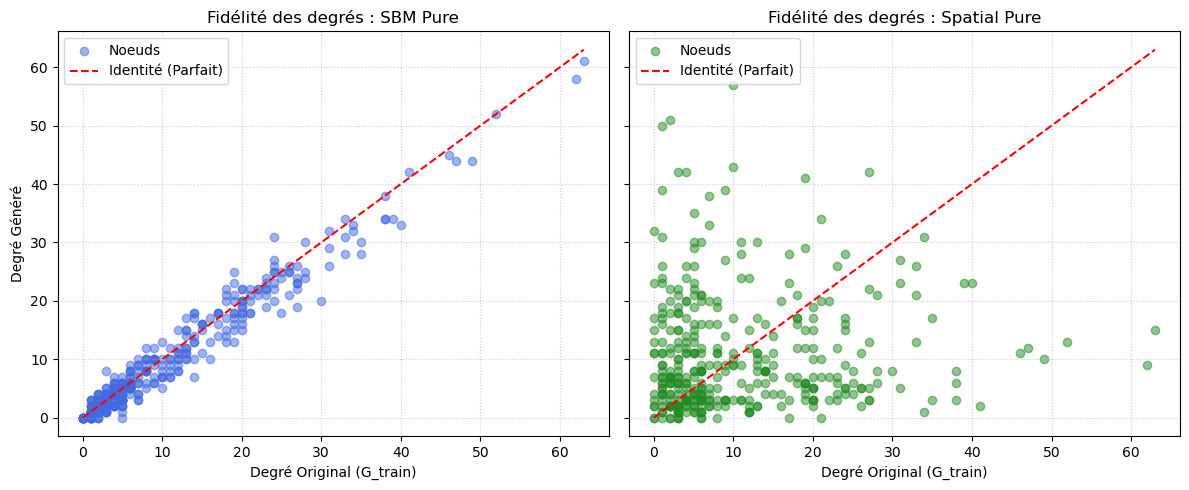

Erreur Moyenne Absolue (MAE) SBM     : 1.65
Erreur Moyenne Absolue (MAE) Spatial : 10.25


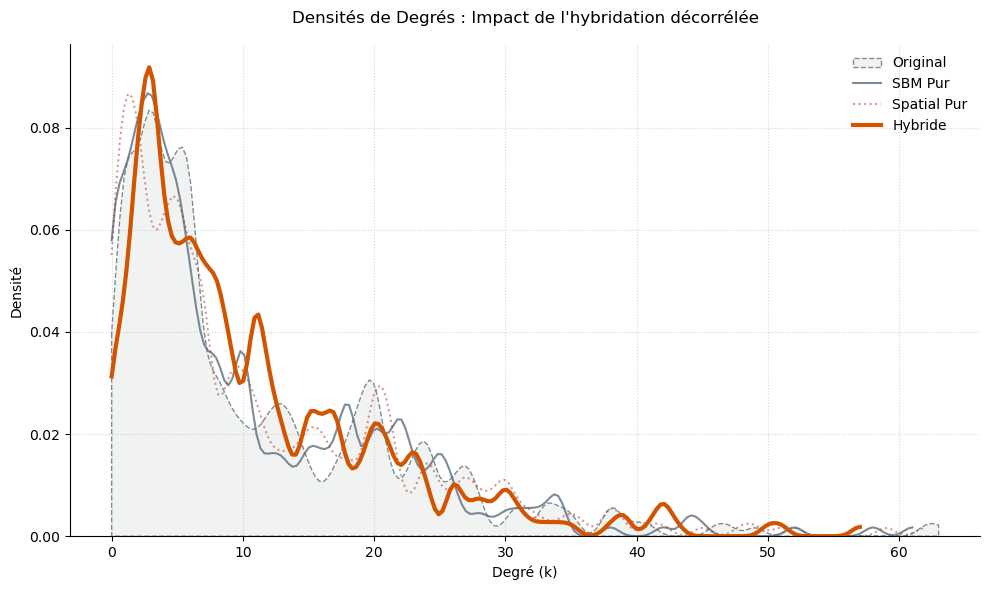

KS Distances -> SBM: 0.0387 | Spatial: 0.0497 | Hybride: 0.0691
Moyennes -> Orig: 10.98 | Hybride: 10.80
Std -> Orig: 10.83 | Hybride: 9.89

Pour ratio_sbm = 0.2



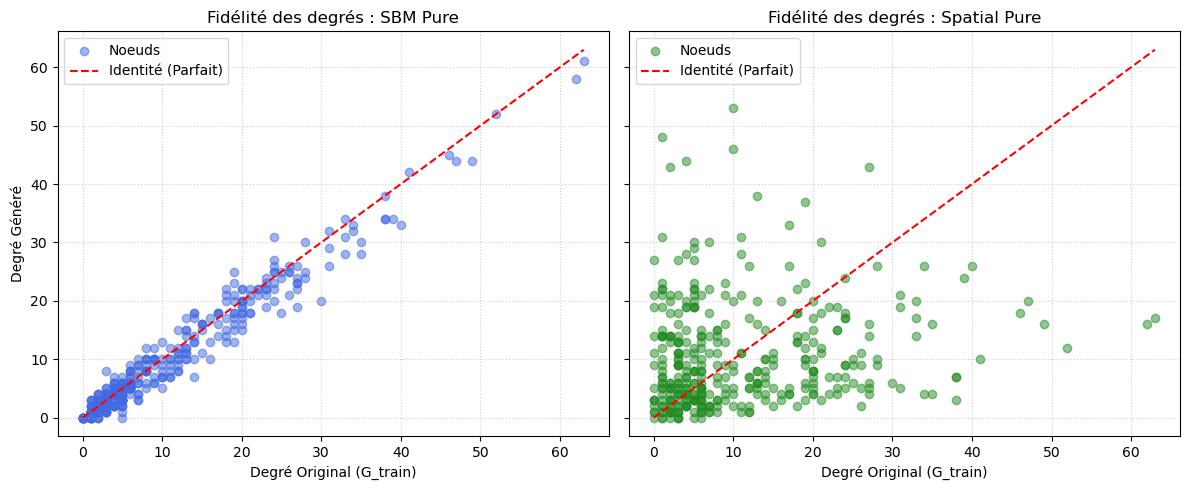

Erreur Moyenne Absolue (MAE) SBM     : 1.65
Erreur Moyenne Absolue (MAE) Spatial : 9.49


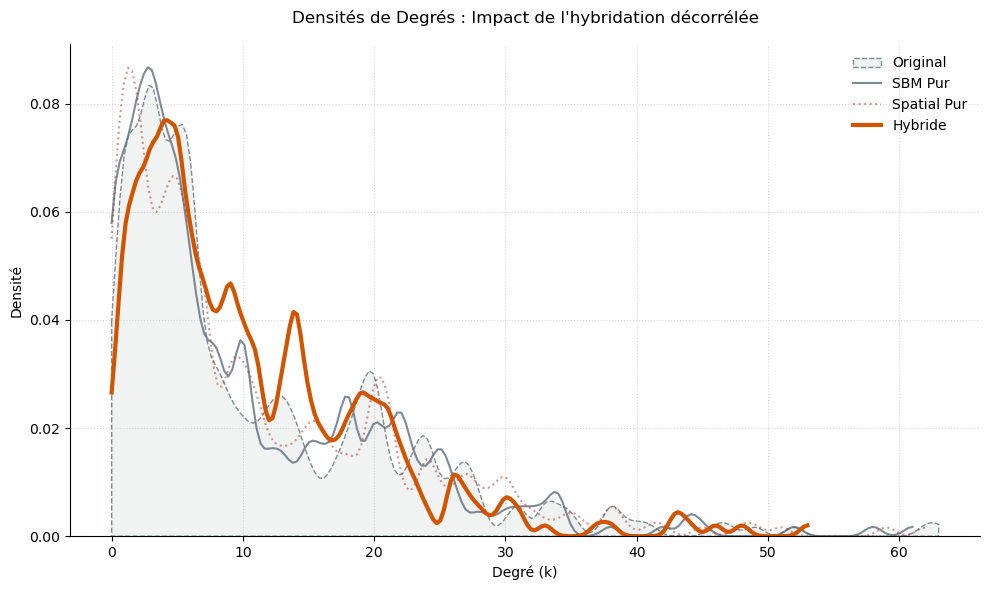

KS Distances -> SBM: 0.0387 | Spatial: 0.0497 | Hybride: 0.0746
Moyennes -> Orig: 10.98 | Hybride: 10.51
Std -> Orig: 10.83 | Hybride: 8.99

Pour ratio_sbm = 0.30000000000000004



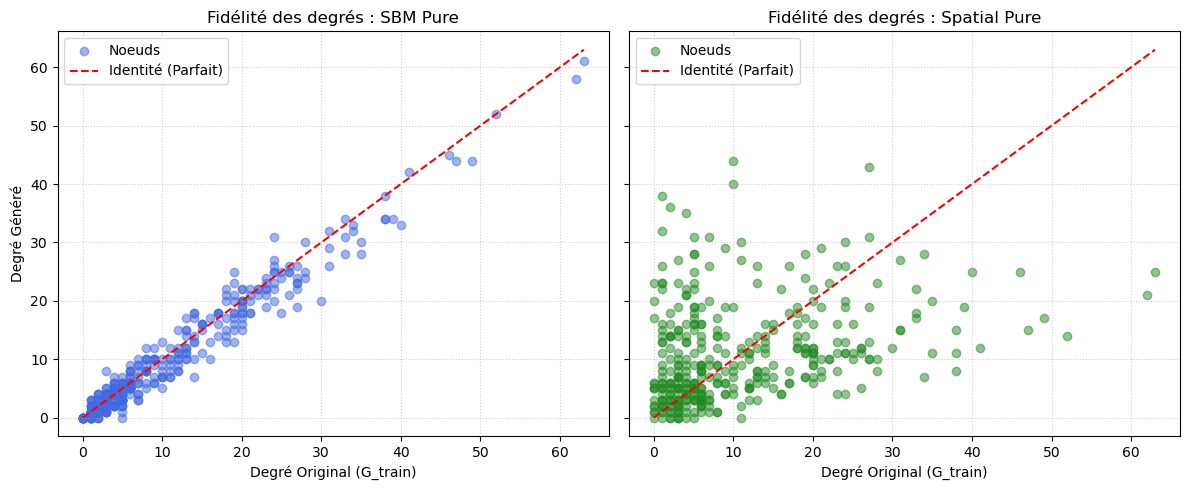

Erreur Moyenne Absolue (MAE) SBM     : 1.65
Erreur Moyenne Absolue (MAE) Spatial : 8.16


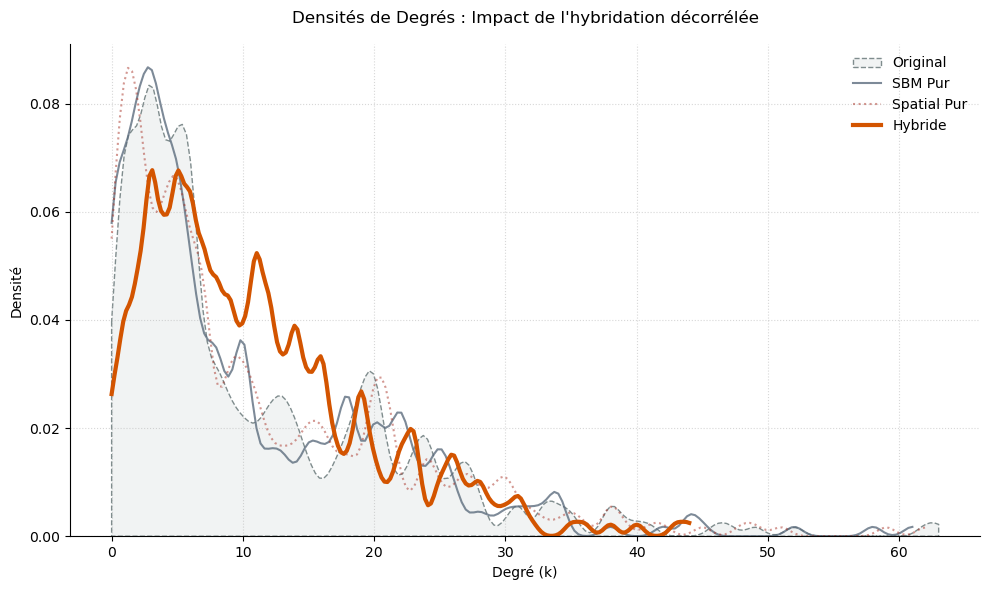

KS Distances -> SBM: 0.0387 | Spatial: 0.0497 | Hybride: 0.1326
Moyennes -> Orig: 10.98 | Hybride: 10.96
Std -> Orig: 10.83 | Hybride: 8.36

Pour ratio_sbm = 0.4



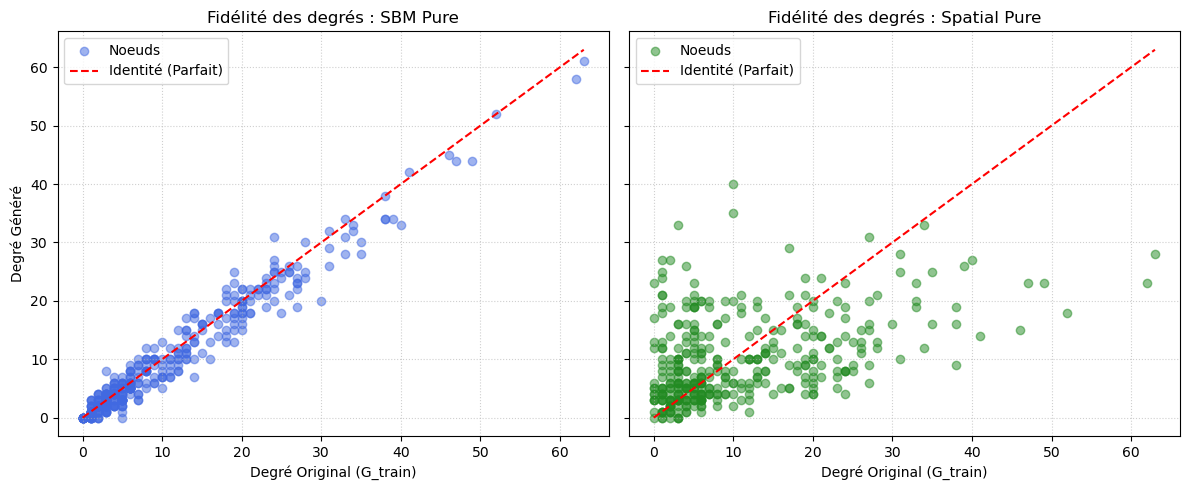

Erreur Moyenne Absolue (MAE) SBM     : 1.65
Erreur Moyenne Absolue (MAE) Spatial : 7.24


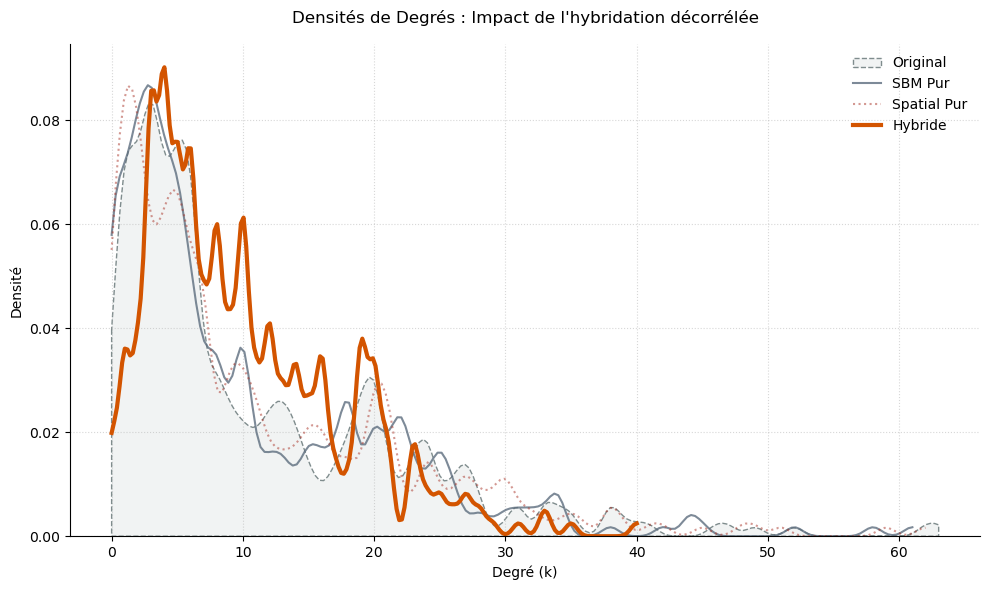

KS Distances -> SBM: 0.0387 | Spatial: 0.0497 | Hybride: 0.1077
Moyennes -> Orig: 10.98 | Hybride: 10.07
Std -> Orig: 10.83 | Hybride: 7.28

Pour ratio_sbm = 0.5



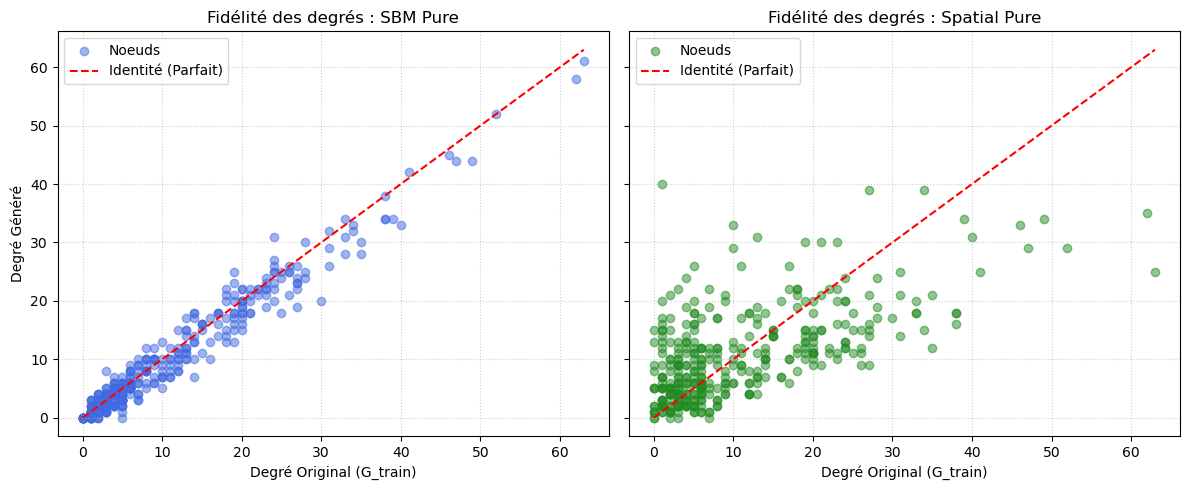

Erreur Moyenne Absolue (MAE) SBM     : 1.65
Erreur Moyenne Absolue (MAE) Spatial : 6.28


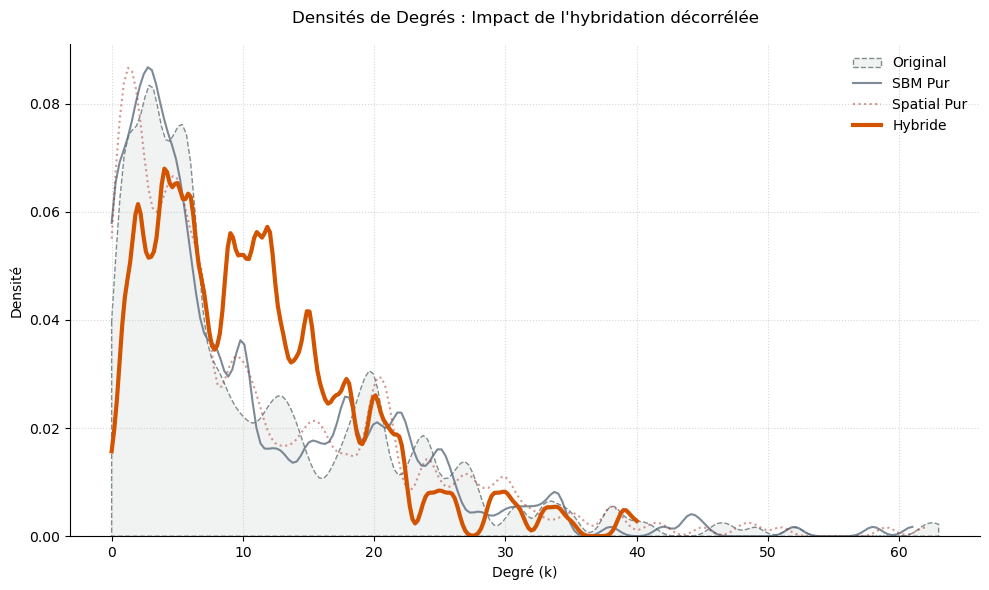

KS Distances -> SBM: 0.0387 | Spatial: 0.0497 | Hybride: 0.1436
Moyennes -> Orig: 10.98 | Hybride: 10.81
Std -> Orig: 10.83 | Hybride: 7.81

Pour ratio_sbm = 0.6



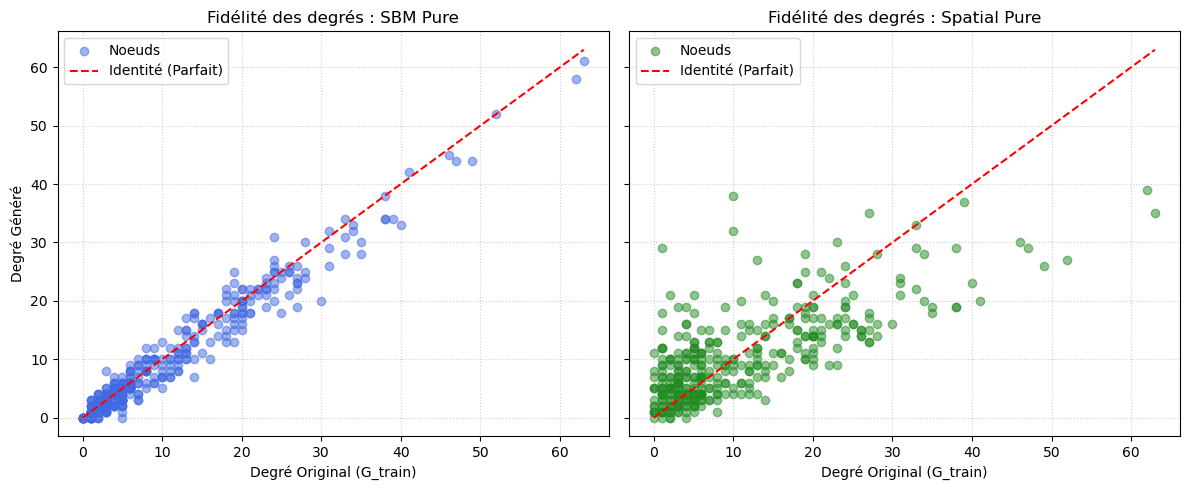

Erreur Moyenne Absolue (MAE) SBM     : 1.65
Erreur Moyenne Absolue (MAE) Spatial : 5.27


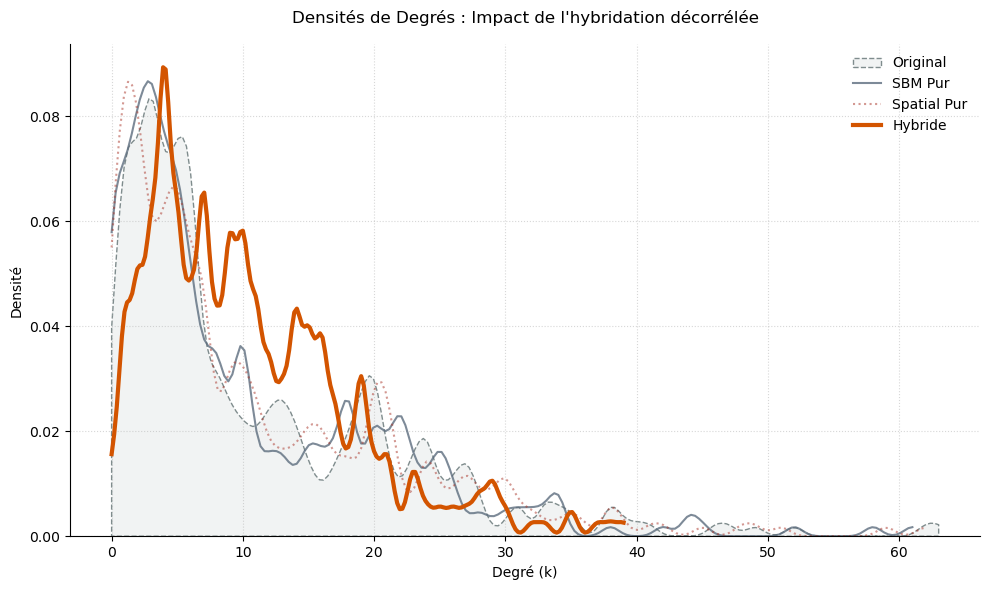

KS Distances -> SBM: 0.0387 | Spatial: 0.0497 | Hybride: 0.1436
Moyennes -> Orig: 10.98 | Hybride: 10.49
Std -> Orig: 10.83 | Hybride: 7.65

Pour ratio_sbm = 0.7000000000000001



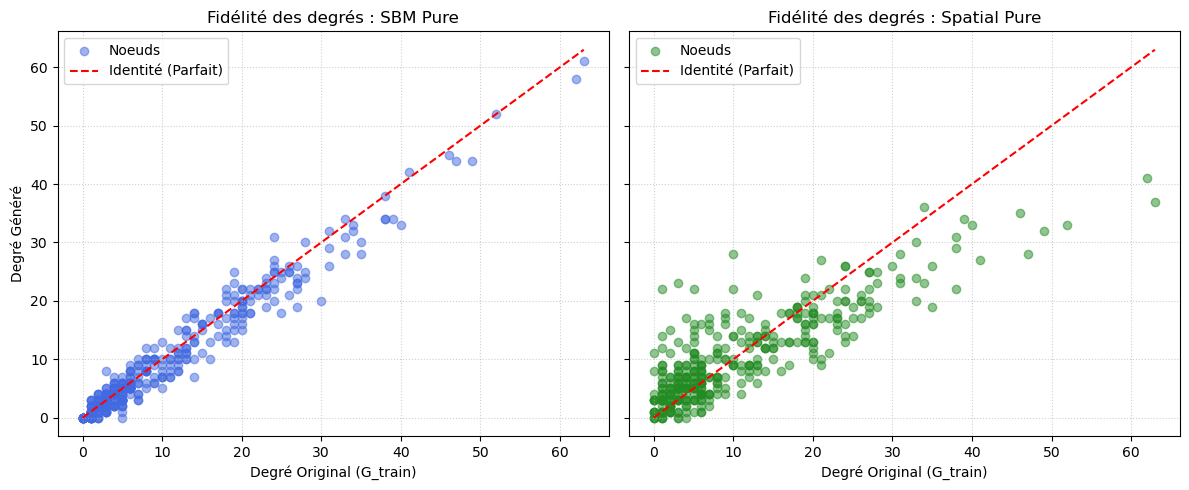

Erreur Moyenne Absolue (MAE) SBM     : 1.65
Erreur Moyenne Absolue (MAE) Spatial : 4.09


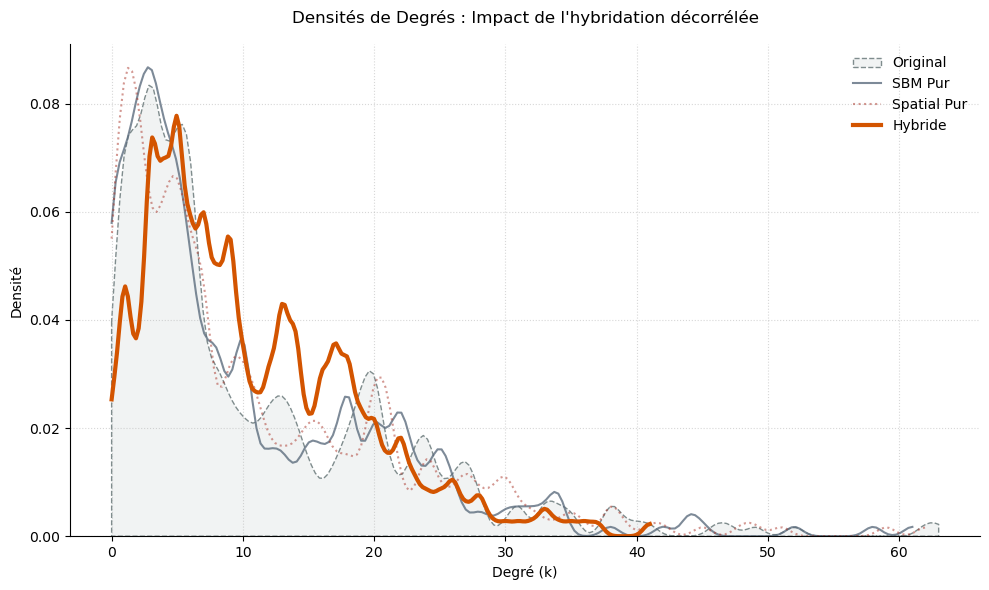

KS Distances -> SBM: 0.0387 | Spatial: 0.0497 | Hybride: 0.1243
Moyennes -> Orig: 10.98 | Hybride: 10.66
Std -> Orig: 10.83 | Hybride: 7.93

Pour ratio_sbm = 0.8



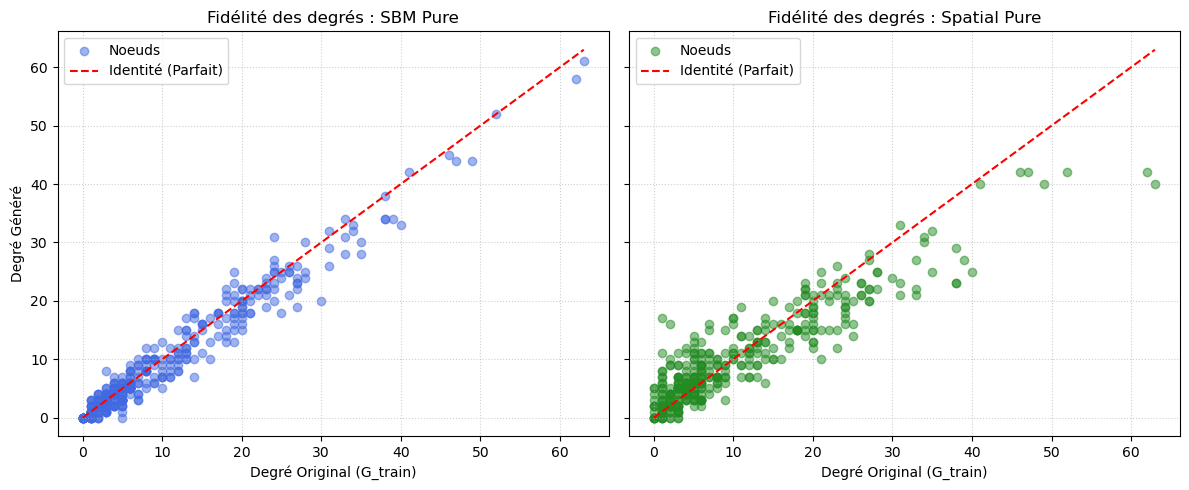

Erreur Moyenne Absolue (MAE) SBM     : 1.65
Erreur Moyenne Absolue (MAE) Spatial : 3.20


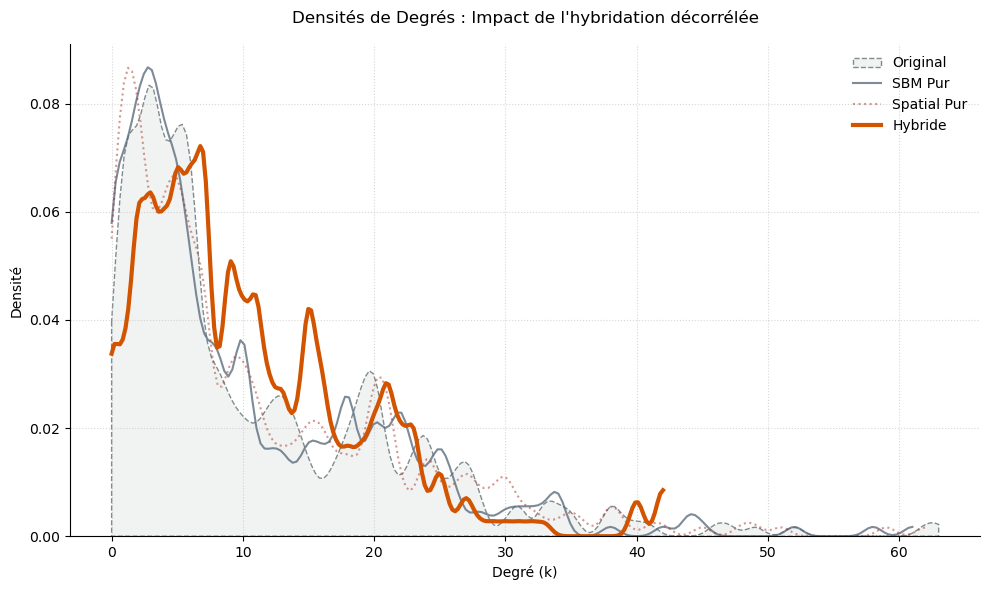

KS Distances -> SBM: 0.0387 | Spatial: 0.0497 | Hybride: 0.1160
Moyennes -> Orig: 10.98 | Hybride: 10.63
Std -> Orig: 10.83 | Hybride: 8.41

Pour ratio_sbm = 0.9



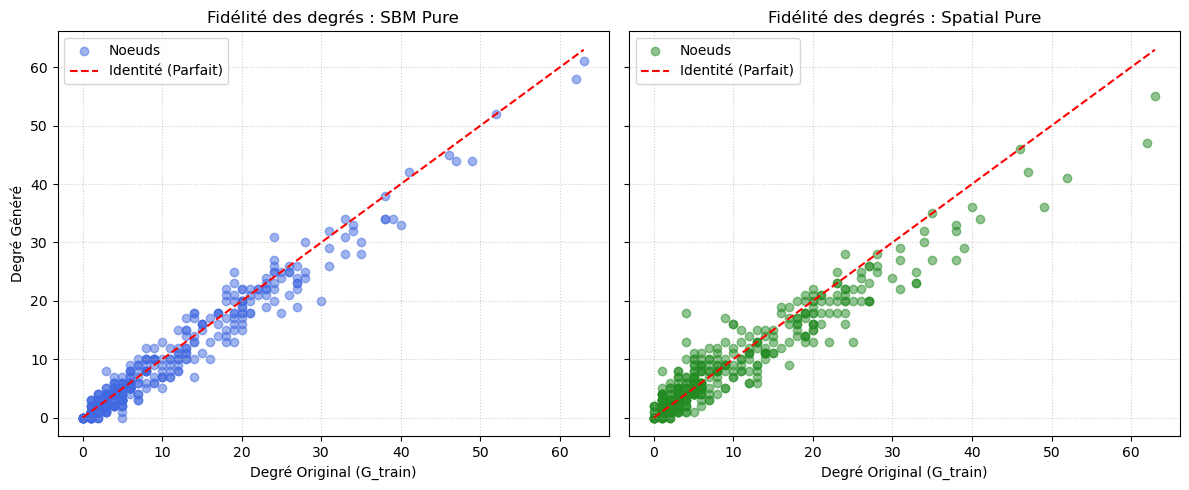

Erreur Moyenne Absolue (MAE) SBM     : 1.65
Erreur Moyenne Absolue (MAE) Spatial : 2.45


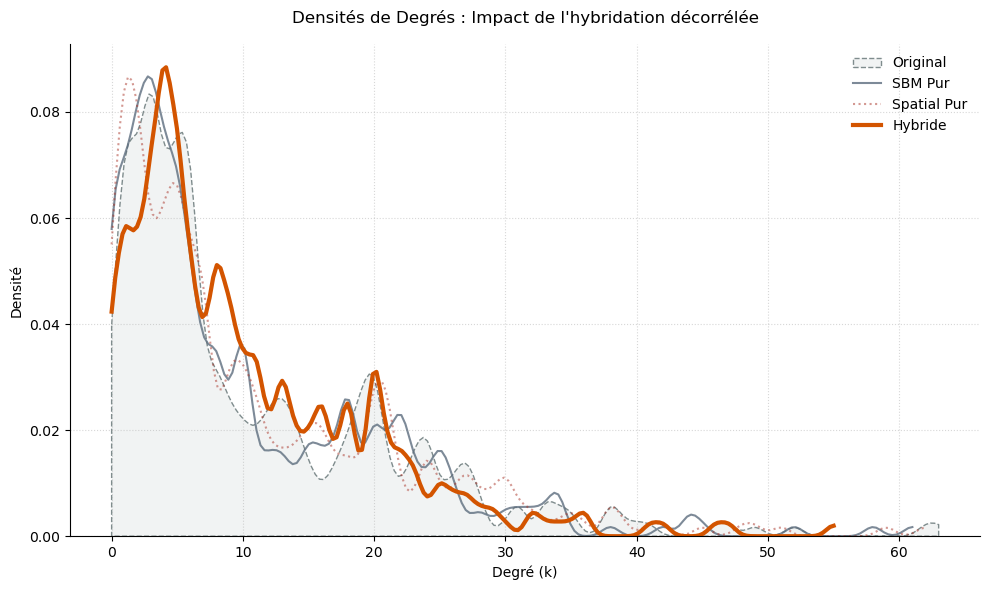

KS Distances -> SBM: 0.0387 | Spatial: 0.0497 | Hybride: 0.0580
Moyennes -> Orig: 10.98 | Hybride: 10.23
Std -> Orig: 10.83 | Hybride: 9.06

📊 TABLEAU RÉCAPITULATIF DE L'HYBRIDATION
              Modèle    N     E    Variance  Entropy Log-Likelihood Clustering
0   Hybride (α=0.10)  362  1955  0.01109005  6316.48       -6261.96     0.2547
1   Hybride (α=0.20)  362  1903  0.00918262  6857.67       -6631.63     0.2127
2   Hybride (α=0.30)  362  1984  0.00781685  7188.27       -7164.16     0.1708
3   Hybride (α=0.40)  362  1823  0.00699275  7353.54       -7028.01     0.1440
4   Hybride (α=0.50)  362  1956  0.00671031  7371.07       -7475.24     0.1436
5   Hybride (α=0.60)  362  1899  0.00696954  7245.39       -7057.48     0.1784
6   Hybride (α=0.70)  362  1930  0.00777044  6970.77       -6977.39     0.2294
7   Hybride (α=0.80)  362  1924  0.00911301  6528.07       -6596.43     0.2775
8   Hybride (α=0.90)  362  1852  0.01099724  5868.91       -5834.87     0.3422
9            SBM Pur  362  1

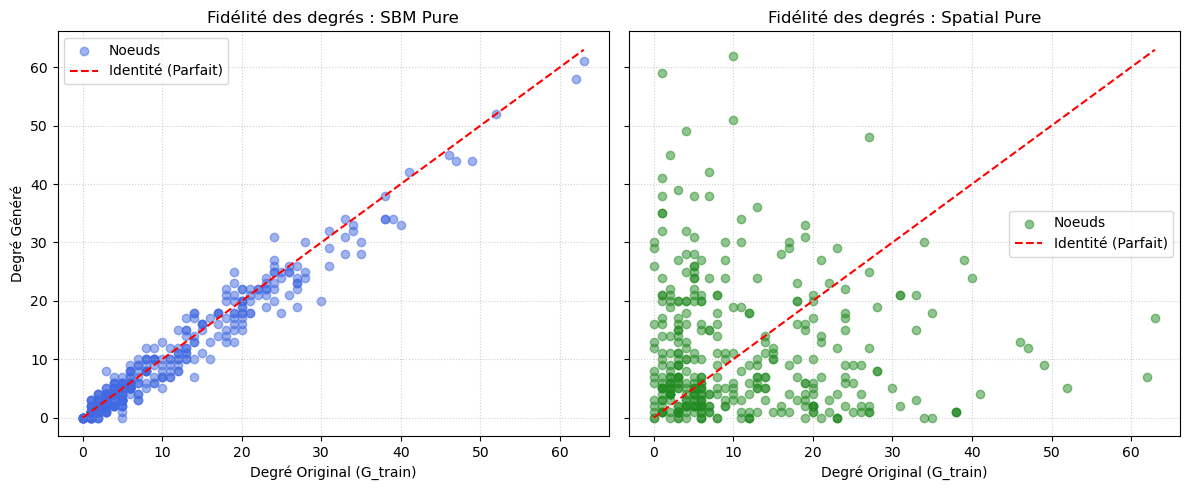

Erreur Moyenne Absolue (MAE) SBM     : 1.65
Erreur Moyenne Absolue (MAE) Spatial : 11.37


In [74]:
G_name = "reel_facebook_friends_w_attributes"
path = f"graph_library/{G_name}"
G = joblib.load(path)

e_rs, k, b = get_real_graph_properties_sbm_V2(G)
P_sbm = get_probs_sbm(e_rs, k, b)

degrees, position = get_real_graph_properties_pos_V2(G)
P_spatial = get_probs_spatial(degrees, position, sigma=12.6738)

g_sbm = generate_graph_from_probs(P_sbm)
g_spatial = generate_graph_from_probs(P_spatial)

g_sbm_nx = convert_to_nx_with_metadata(g_sbm, position, b)
g_spatial_nx = convert_to_nx_with_metadata(g_spatial, position, b)
save_as_graphml(g_sbm_nx, filename="artificial_graph_sbmv3_shuffled_1_00_pos_0_00.graphml")
save_as_graphml(g_spatial_nx, filename="artificial_graph_sbmv3_shuffled_0_00_pos_1_00.graphml")

results_list = []

for alpha in np.arange(0.1, 1.0, 0.1):
    G_name = f"artificial_graph_sbmv3_shuffled_{f'{alpha:.2f}'.replace('.', '_')}_pos_{f'{1-alpha:.2f}'.replace('.', '_')}.graphml"

    print("\n" + "="*90)
    print(f"Pour ratio_sbm = {alpha}")
    print("\n" + "="*90)
    
    P_hybride = P_sbm * alpha + P_spatial * (1 - alpha)
    g_hybride = generate_graph_from_probs(P_hybride)

    g_hybride_nx = convert_to_nx_with_metadata(g_hybride, position, b)
    save_as_graphml(g_hybride_nx, filename=G_name)
    
    var_h = get_variance_from_P(P_hybride)
    ent_h = get_entropy_from_p(P_hybride)
    ll_h = get_log_likelihood(g_hybride, P_hybride)
    
    clustering = gt.global_clustering(g_hybride)[0]  
    
    results_list.append({
        "Modèle": f"Hybride (α={alpha:.2f})",
        "N": g_hybride.num_vertices(),
        "E": g_hybride.num_edges(),
        "Variance": f"{var_h:.8f}",
        "Entropy": f"{ent_h:.2f}",
        "Log-Likelihood": f"{ll_h:.2f}",
        "Clustering": f"{clustering:.4f}"
    })

    plot_degree_correlation(k, g_sbm, g_hybride)
    plot_degree_distribution(k, g_sbm, g_spatial, g_hybride)

modeles_baselines = {
    "SBM Pur": (P_sbm, g_sbm),
    "Spatial Pur": (P_spatial, g_spatial)
}

for name, (P, g) in modeles_baselines.items():
    var_val = get_variance_from_P(P)
    ent_val = get_entropy_from_p(P)
    ll_val = get_log_likelihood(g, P)

    clustering = gt.global_clustering(g)[0]    
    
    results_list.append({
        "Modèle": name,
        "N": g.num_vertices(),
        "E": g.num_edges(),
        "Variance": f"{var_val:.8f}",
        "Entropy": f"{int(ent_val)}",
        "Log-Likelihood": f"{ll_val:.2f}",
        "Clustering": f"{clustering:.4f}"
    })

# --- Affichage final ---
df_results = pd.DataFrame(results_list)

print("\n" + "="*90)
print("📊 TABLEAU RÉCAPITULATIF DE L'HYBRIDATION")
print("="*90)
print(df_results)
print("="*90)

plot_degree_correlation(k, g_sbm, g_spatial)

In [30]:
G_name = "reel_facebook_friends_w_attributes"
path = f"graph_library/{G_name}"
G = joblib.load(path)

e_rs, k, b = get_real_graph_properties_sbm_V2(G)
P_sbm = get_probs_sbm(e_rs, k, b)

degrees, position = get_real_graph_properties_pos_V2(G, shuffle=False)
P_spatial = get_probs_spatial(degrees, position, sigma=12.6738)

g_sbm = generate_graph_from_probs(P_sbm)
g_spatial = generate_graph_from_probs(P_spatial)

results_list = []

for alpha in np.arange(0.1, 1.0, 0.1):
    P_hybride = P_sbm * alpha + P_spatial * (1 - alpha)
    g_hybride = generate_graph_from_probs(P_hybride)
    
    var_h = get_variance_from_P(P_hybride)
    ent_h = get_entropy_from_p(P_hybride)
    ll_h = get_log_likelihood(g_hybride, P_hybride)
    
    clustering = gt.global_clustering(g_hybride)[0]    
    
    results_list.append({
        "Modèle": f"Hybride (α={alpha:.2f})",
        "N": g_hybride.num_vertices(),
        "E": g_hybride.num_edges(),
        "Variance": f"{var_h:.8f}",
        "Entropy": f"{ent_h:.2f}",
        "Log-Likelihood": f"{ll_h:.2f}",
        "Clustering": f"{clustering:.4f}"
    })

modeles_baselines = {
    "SBM Pur": (P_sbm, g_sbm),
    "Spatial Pur": (P_spatial, g_spatial)
}

for name, (P, g) in modeles_baselines.items():
    var_val = get_variance_from_P(P)
    ent_val = get_entropy_from_p(P)
    ll_val = get_log_likelihood(g, P)

    clustering = gt.global_clustering(g)[0]    
    
    results_list.append({
        "Modèle": name,
        "N": g.num_vertices(),
        "E": g.num_edges(),
        "Variance": f"{var_val:.8f}",
        "Entropy": f"{int(ent_val)}",
        "Log-Likelihood": f"{ll_val:.2f}",
        "Clustering": f"{clustering:.4f}"
    })

# --- Affichage final ---
df_results = pd.DataFrame(results_list)

print("\n" + "="*90)
print("📊 TABLEAU RÉCAPITULATIF DE L'HYBRIDATION")
print("="*90)
print(df_results)
print("="*90)

Erreur moyenne sur les degrés (MAE) : 0.012555

📊 TABLEAU RÉCAPITULATIF DE L'HYBRIDATION
              Modèle    N     E    Variance  Entropy Log-Likelihood Clustering
0   Hybride (α=0.10)  362  1986  0.01264805  5477.49       -5446.91     0.3938
1   Hybride (α=0.20)  362  2033  0.01249636  5505.19       -5632.03     0.3912
2   Hybride (α=0.30)  362  2012  0.01240413  5505.97       -5570.08     0.3899
3   Hybride (α=0.40)  362  1912  0.01237135  5482.50       -5460.86     0.3932
4   Hybride (α=0.50)  362  1934  0.01239802  5435.55       -5468.89     0.3911
5   Hybride (α=0.60)  362  1945  0.01248414  5364.77       -5435.68     0.3954
6   Hybride (α=0.70)  362  1890  0.01262971  5268.65       -5174.88     0.4091
7   Hybride (α=0.80)  362  1916  0.01283474  5144.11       -5174.76     0.4134
8   Hybride (α=0.90)  362  1867  0.01309921  4984.76       -4973.70     0.4233
9            SBM Pur  362  1826  0.01342314     4769       -4640.33     0.4322
10       Spatial Pur  362  1926  0.0128591